# Process chains of the technology options as modelled in FLEXIMOD

**Block-flow diagrams of all 19 cement routes and all 18 steel configurations.**

Companion to `investment_decision_chain_analysis.ipynb`. That notebook explains *which* technology is chosen and why; this one documents *what each technology is*, as it is represented in the optimisation model.

**How the diagrams were made.**

* The set of stages, their fuel modes, the electrolyser and the capture block of each configuration are **read from the `plants.csv` of the corresponding FLEXIMOD input case** when the notebook runs. A diagram therefore cannot disagree with the simulated plant.
* The links between the blocks (which stream goes where) were checked against the Pyomo model: `CementPlant.initialize_process_sequence` and the technology blocks in `src/flexi_mod/plants/technologies.py` for cement, `SteelPlant.initialize_process_sequence` and the steel blocks for steel. The most important links are listed below.
* The diagrams show the **physical and energy structure**. Dispatch details (ramping, minimum run times, commitment binaries, rolling horizon, market products) are not drawn.

**Reading key.** Boxes are process stages. The tint shows the stage's fuel mode (grey: coal and gas, blue: electricity, green: hydrogen; two tints: the optimiser may mix the two fuels). Black arrows are product flows, coloured arrows are energy and material inputs, red lines are CO2 that is emitted, green arrows are CO2 that is captured or separated, dashed lines are oxygen and heat. All figures are also written as vector PDF and PNG to `data/output/process_flow_diagrams/` for use in papers.

### Links verified in the Pyomo model

**Cement** (`cement_plant.py`, `initialize_process_sequence`)

| Link | Model relation |
|---|---|
| Raw meal | the calciner's (or, without a calciner, the kiln's) clinker output equals the preheater's raw-meal output divided by the raw-meal-to-clinker ratio |
| Calciner to kiln | `kiln.clinker_out == calciner.clinker_out` |
| Waste heat | `preheater.external_heat_in == kiln.clinker_out x waste_heat_per_t_clinker x waste_heat_utilization_efficiency` |
| Demand | the terminal stage's clinker output is at least the clinker demand and at most the demand times (1 + overproduction tolerance) |
| Amine and cryogenic CCS | receive the CO2 of preheater, calciner and kiln |
| Oxyfuel CO2 recovery | receives only the CO2 of the stages that are oxyfuel stages; a conventional stage on the same line (the preheater, or the kiln in R10) sends its CO2 to the stack |
| Hydrogen | with an electrolyser, `electrolyser.hydrogen_out` equals the hydrogen demand of calciner plus kiln (the preheater has none); without one, hydrogen is bought |
| Oxygen | oxygen demand follows from the fuel burned in an oxyfuel stage; the electrolyser's co-product oxygen covers part of it, the rest is generated inside the stage with electricity |
| Process CO2 | calcination CO2 belongs to the calciner whatever its fuel; LEILAC separates a fraction of it directly |
| Capture inputs | amine CCS draws electricity and heat in proportion to the CO2 captured; cryogenic CCS and oxyfuel recovery draw electricity only |
| Auxiliary power | every kiln-line stage also draws auxiliary electricity in proportion to its throughput (not drawn) |

**Steel** (`steel_plant.py`, `initialize_process_sequence`)

| Link | Model relation |
|---|---|
| Reduction | DRI output equals fuel input divided by the specific consumption; for the hybrid fuel the gas and hydrogen contributions add up, so the optimiser can mix them |
| DRI to converter | `dri.dri_output == terminal.dri_input` (a DRI buffer exists in the model but is not part of any configuration) |
| Converter | steel output equals DRI input divided by the specific DRI demand; electricity and lime are proportional to steel output |
| BF-BOF | one block: steel output equals fuel input divided by the specific consumption; iron ore, lime and electricity are proportional to steel output |
| CO2 | fuel CO2 (coal, natural gas) in the reduction stage or BF-BOF block, lime CO2 in the converter; hydrogen burns without CO2 |
| Hydrogen | with an electrolyser, hydrogen output equals the hydrogen demand (no buffer in these configurations); without one it is bought at the hydrogen price |
| Electrolyser oxygen | computed as a co-product but not used by any steel stage |

In [1]:
# Drawing helpers and the technology definitions (the code behind all figures)
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch, Rectangle

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix", "axes.unicode_minus": False,
})


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate the FLEXIMOD project root.")


FLEX = find_project_root()
CEMENT_INPUTS = FLEX / "data" / "input" / "cement_inputs"
STEEL_INPUTS = FLEX / "data" / "input" / "steel_inputs"
FIG_DIR = FLEX / "data" / "output" / "process_flow_diagrams"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FIGURES = True          # also write every diagram as vector PDF and PNG to FIG_DIR

C = {"coal": "#4d4d4d", "gas": "#d98c00", "h2": "#1b9e77", "elec": "#2166ac", "heat": "#a6611a",
     "co2": "#b2182b", "cap": "#1b7837", "o2": "#6f93c4", "mat": "#111111", "ore": "#8c564b", "lime": "#8a8a8a",
     "biomass": "#7f9d3b", "rdf": "#c26b8a"}
FUEL_TINT = {"fossil": [C["coal"]], "coal": [C["coal"]], "natural_gas": [C["gas"]], "electricity": [C["elec"]],
             "hydrogen": [C["h2"]], "hybrid_electricity_fossil": [C["elec"], C["coal"]],
             "hybrid_hydrogen_natural_gas": [C["h2"], C["gas"]], "none": ["#999999"]}
W, H = 19.0, 9.4        # canvas in data units


def canvas(title: str, tag: str, ymin: float = 0.0, ymax: float = H):
    fig, ax = plt.subplots(figsize=(14.2, 7.0 * (ymax - ymin) / H))
    ax.set_xlim(0, W); ax.set_ylim(ymin, ymax); ax.axis("off"); ax.set_aspect("auto")
    ax.text(0.05, ymax - 0.1, tag, fontsize=14, fontweight="bold", va="top")
    ax.text(0.05, ymax - 0.62, title, fontsize=11, va="top", style="italic")
    return fig, ax


def arrow(ax, pts, color, lw=1.7, ls="-", head=True):
    """Orthogonal polyline; the last segment carries the arrow head."""
    xs, ys = zip(*pts)
    if len(pts) > 2:
        ax.plot(xs[:-1], ys[:-1], color=color, lw=lw, ls=ls, solid_capstyle="butt", zorder=2)
    ax.annotate("", xy=pts[-1], xytext=pts[-2], zorder=2,
                arrowprops=dict(arrowstyle="-|>" if head else "-", color=color, lw=lw, linestyle=ls, shrinkA=0, shrinkB=0, mutation_scale=12))


def block(ax, x0, x1, y0, y1, title, sub="", tint=("#999999",), bold=True):
    n = len(tint)
    for i, c in enumerate(tint):
        ax.add_patch(Rectangle((x0 + (x1 - x0) * i / n, y0), (x1 - x0) / n, y1 - y0, facecolor=c, alpha=0.16, edgecolor="none", zorder=1))
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, facecolor="none", edgecolor="black", linewidth=1.3, zorder=3))
    cy = (y0 + y1) / 2
    ax.text((x0 + x1) / 2, cy + (0.2 if sub else 0), title, ha="center", va="center", fontsize=11, fontweight="bold" if bold else "normal", zorder=4)
    if sub:
        ax.text((x0 + x1) / 2, cy - 0.28, sub, ha="center", va="center", fontsize=8.6, style="italic", zorder=4)


def label(ax, x, y, s, color="black", ha="center", va="top", fs=8.8, **kw):
    ax.text(x, y, s, ha=ha, va=va, fontsize=fs, color=color, zorder=5, **kw)


def legend(fig, entries):
    handles = [plt.Line2D([0], [0], color=c, lw=2.6, ls=ls, label=l) for l, c, ls in entries]
    fig.legend(handles=handles, loc="lower center", ncol=len(entries), fontsize=8.4, frameon=False, bbox_to_anchor=(0.5, 0.0), handlelength=2.2, columnspacing=1.4)


def finish(fig, name, entries):
    legend(fig, entries)
    fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.07)
    if SAVE_FIGURES:
        fig.savefig(FIG_DIR / f"{name}.pdf"); fig.savefig(FIG_DIR / f"{name}.png")
    plt.show()
    plt.close(fig)


LEGEND_CEMENT = [("product / material flow", C["mat"], "-"), ("coal, natural gas (biomass, RDF)", C["coal"], "-"), ("electricity", C["elec"], "-"),
                 ("hydrogen", C["h2"], "-"), ("oxygen", C["o2"], "--"), ("heat", C["heat"], "--"), ("CO₂ emitted", C["co2"], "-"), ("CO₂ captured", C["cap"], "-")]
LEGEND_STEEL = [("product / material flow", C["mat"], "-"), ("iron ore", C["ore"], "-"), ("lime", C["lime"], "-"), ("coal", C["coal"], "-"), ("natural gas", C["gas"], "-"),
                ("hydrogen", C["h2"], "-"), ("electricity", C["elec"], "-"), ("oxygen", C["o2"], "--"), ("CO₂ emitted", C["co2"], "-")]


# ----------------------------------------------------------------------------- cement
CEMENT_STAGE_TECH = ("preheater", "simple_calciner", "leilac_calciner", "oxyfuel_calciner", "simple_kiln", "oxyfuel_kiln")


def cement_spec(route: str) -> dict:
    """Stages and fuel modes of a route, read from its FLEXIMOD plants.csv (first plant)."""
    folder = next(p for p in CEMENT_INPUTS.glob("technologiemix_2040_*") if p.name.split("_", 2)[2].lower() == route.lower())
    p = pd.read_csv(folder / "plants.csv")
    q = p[p.name == p.name.iloc[0]].set_index("technology")
    spec = {"stage": {}, "ccs": None, "electrolyser": "electrolyser" in q.index,
            "storage": [t for t in ("thermal_storage", "hydrogen_buffer_storage") if t in q.index]}
    for tech, row in q.iterrows():
        if tech in CEMENT_STAGE_TECH:
            spec["stage"][tech] = row["fuel_type"]
        elif tech.endswith("_ccs"):
            spec["ccs"] = tech
    r = q.loc["preheater"]
    spec["biomass"], spec["rdf"] = float(r.get("biomass_share", 0) or 0), float(r.get("rdf_share", 0) or 0)
    return spec


def draw_cement(route: str, desc: str):
    s = cement_spec(route)
    st = s["stage"]
    cal = next(k for k in st if k.endswith("calciner"))
    kil = next(k for k in st if k.endswith("kiln"))
    ely = s["electrolyser"]
    fig, ax = canvas(desc, route, 0.0 if ely else 2.0, 9.0 if (s['ccs'] or cal == 'leilac_calciner') else 7.6)
    X = {"pre": (2.0, 4.9), "cal": (6.9, 9.9), "kil": (11.9, 14.8)}
    YM, HB = 4.55, 0.78
    y0, y1 = YM - HB, YM + HB
    names = {"pre": ("Preheater", "raw-meal heating"),
             "cal": ("Calciner", {"simple_calciner": "conventional", "leilac_calciner": "LEILAC, indirectly heated", "oxyfuel_calciner": "oxyfuel"}[cal]),
             "kil": ("Kiln", {"simple_kiln": "conventional", "oxyfuel_kiln": "oxyfuel"}[kil])}
    modes = {"pre": st["preheater"], "cal": st[cal], "kil": st[kil]}
    oxy = {"pre": False, "cal": cal.startswith("oxyfuel"), "kil": kil.startswith("oxyfuel")}
    for k, (a, b) in X.items():
        block(ax, a, b, y0, y1, *names[k], FUEL_TINT[modes[k]])
    # material chain
    arrow(ax, [(0.2, YM), (X["pre"][0], YM)], C["mat"], 2.0); label(ax, 0.2, YM + 0.12, "raw meal", ha="left", va="bottom")
    arrow(ax, [(X["pre"][1], YM), (X["cal"][0], YM)], C["mat"], 2.0); label(ax, (X["pre"][1] + X["cal"][0]) / 2, YM + 0.12, "raw meal", va="bottom", fs=8)
    arrow(ax, [(X["cal"][1], YM), (X["kil"][0], YM)], C["mat"], 2.0); label(ax, (X["cal"][1] + X["kil"][0]) / 2, YM + 0.12, "calcined meal", va="bottom", fs=8)
    arrow(ax, [(X["kil"][1], YM), (W - 0.3, YM)], C["mat"], 2.4); label(ax, (X["kil"][1] + W - 0.3) / 2, YM - 0.15, "clinker\n(meets demand)", fontweight="bold")
    # waste heat: kiln -> preheater
    ywh = 5.78
    arrow(ax, [(X["kil"][0] + 0.45, y1), (X["kil"][0] + 0.45, ywh), (X["pre"][1] - 0.45, ywh), (X["pre"][1] - 0.45, y1)], C["heat"], 1.5, "--")
    label(ax, (X["pre"][1] + X["cal"][0]) / 2 + 0.2, ywh + 0.07, "waste heat from kiln", C["heat"], va="bottom", fs=8)
    # stage inputs from below
    YL, YA = 3.0, 3.1
    ybus_h2, ybus_o2 = 2.35, 1.95
    ely_x = None
    inputs = {}
    for k in ("pre", "cal", "kil"):
        m = modes[k]; items = []
        if m == "fossil":
            lab = "coal · gas" if not (s["biomass"] or s["rdf"]) else "coal · gas ·\nbiomass · RDF"
            items.append(("fuel", lab, C["coal"]))
        elif m == "electricity":
            items.append(("fuel", "electricity", C["elec"]))
        elif m == "hybrid_electricity_fossil":
            items += [("fuel", "electricity", C["elec"]), ("fuel", "coal · gas", C["coal"])]
        elif m == "hydrogen":
            items.append(("h2", "H₂", C["h2"]))
        if oxy[k]:
            if ely:
                items.append(("o2", "O₂", C["o2"]))
            items.append(("fuel", "electricity\n(remaining O₂)", C["elec"]))
        inputs[k] = items
    ely_slots = {"h2": [], "o2": []}
    for k, items in inputs.items():
        a, b = X[k]; n = len(items)
        for i, (kind, lab, col) in enumerate(items):
            x = a + (i + 1) * (b - a) / (n + 1)
            if kind in ("h2", "o2") and ely:
                ely_slots[kind].append((x, k))
                ybase = ybus_h2 if kind == "h2" else ybus_o2
                arrow(ax, [(x, ybase), (x, y0)], col, 1.7, "--" if kind == "o2" else "-")
            else:
                dy = (i % 2) * 0.62 if n >= 3 else 0.0
                arrow(ax, [(x, YA - dy), (x, y0)], col, 1.7)
                label(ax, x, YL - 0.02 - dy, lab + ("\n(network)" if kind == "h2" else ""), "black")
    if ely:
        hx = [x for x, _ in ely_slots["h2"]]
        xe = (min(hx) + max(hx)) / 2
        block(ax, xe - 1.55, xe + 1.55, 0.35, 1.45, "Electrolyser", "H₂ + O₂ co-product", (C["h2"],))
        arrow(ax, [(xe - 4.2, 0.9), (xe - 1.55, 0.9)], C["elec"], 1.7); label(ax, xe - 4.2, 0.98, "electricity", ha="left", va="bottom")
        xh = xe - 0.55
        arrow(ax, [(xh, 1.45), (xh, ybus_h2)], C["h2"], 1.7, head=False); label(ax, xh - 0.1, 1.9, "H\u2082", C["h2"], ha="right", va="center")
        ax.plot([min(hx), max(hx)], [ybus_h2, ybus_h2], color=C["h2"], lw=1.7, zorder=2)
        if ely_slots["o2"]:
            ox = [x for x, _ in ely_slots["o2"]]
            xo = xe + 0.55
            arrow(ax, [(xo, 1.45), (xo, ybus_o2)], C["o2"], 1.5, "--", head=False); label(ax, xo + 0.1, 1.7, "O\u2082", C["o2"], ha="left", va="center")
            ax.plot([min(ox + [xo]), max(ox + [xo])], [ybus_o2, ybus_o2], color=C["o2"], lw=1.5, ls="--", zorder=2)
    # CO2 routing
    ccs = s["ccs"]
    oxy_stages = {k for k in ("cal", "kil") if oxy[k]}
    emitters = [k for k in ("pre", "cal", "kil") if k == "cal" or modes[k] in ("fossil", "hybrid_electricity_fossil")]
    to_ccs = [k for k in emitters if ccs and (ccs != "oxyfuel_ccs" or k in oxy_stages)]
    to_stack = [k for k in emitters if k not in to_ccs]
    YS, YC = 6.45, 7.05
    rx = {"pre": X["pre"][0] + 0.6, "cal": X["cal"][1] - 0.6, "kil": X["kil"][1] - 0.6}
    CCS_X0 = 15.2
    for k in to_stack:
        arrow(ax, [(rx[k], y1), (rx[k], YS)], C["co2"], 1.5, head=False)
    for k in to_ccs:
        arrow(ax, [(rx[k], y1), (rx[k], YC)], C["co2"], 1.5, head=False)
    if to_stack:
        xend = 14.6 if ccs else 17.6
        ax.plot([min(rx[k] for k in to_stack), xend - 0.4], [YS, YS], color=C["co2"], lw=1.5, zorder=2)
        arrow(ax, [(xend - 0.5, YS), (xend, YS)], C["co2"], 1.5)
        label(ax, xend + 0.25, YS, "to stack", C["co2"], ha="left", va="center")
        label(ax, rx[to_stack[0]] + 0.1, YS - 0.07, "CO₂ to stack" if not ccs else "CO₂ not routed to capture", C["co2"], ha="left", va="top", fs=8.3)
    if to_ccs:
        ax.plot([min(rx[k] for k in to_ccs), CCS_X0 - 0.3], [YC, YC], color=C["co2"], lw=1.5, zorder=2)
        arrow(ax, [(CCS_X0 - 0.4, YC), (CCS_X0, YC)], C["co2"], 1.5)
        label(ax, rx[to_ccs[0]] + 0.1, YC + 0.07, "flue-gas CO₂ to capture unit", C["co2"], ha="left", va="bottom", fs=8.3)
    if ccs:
        cname = {"amine_ccs": "Amine CCS", "cryogenic_ccs": "Cryogenic CCS", "oxyfuel_ccs": "Oxyfuel CO₂\nrecovery"}[ccs]
        block(ax, CCS_X0, 17.8, 6.5, 7.6, cname, "", (C["cap"],))
        arrow(ax, [(15.9, 8.55), (15.9, 7.6)], C["elec"], 1.6); label(ax, 15.9, 8.62, "electricity", va="bottom", fs=8.3)
        if ccs == "amine_ccs":
            arrow(ax, [(17.0, 8.55), (17.0, 7.6)], C["heat"], 1.6, "--"); label(ax, 17.0, 8.62, "heat", C["heat"], va="bottom", fs=8.3)
        arrow(ax, [(17.8, 7.05), (18.7, 7.05)], C["cap"], 1.8); label(ax, 18.25, 7.17, "captured\nCO₂", C["cap"], va="bottom", fs=8.3)
        arrow(ax, [(16.5, 6.5), (16.5, 5.95)], C["co2"], 1.5); label(ax, 16.6, 6.2, "residual\nCO₂", C["co2"], ha="left", va="center", fs=8.3)
    if cal == "leilac_calciner":
        x = X["cal"][0] + 0.6
        arrow(ax, [(x, y1), (x, 8.45)], C["cap"], 1.8)
        label(ax, x, 8.52, "separated process CO₂", C["cap"], va="bottom", fs=8.6)
    if oxy["cal"] or oxy["kil"]:
        pass
    finish(fig, f"cement_{route}", LEGEND_CEMENT)


# ----------------------------------------------------------------------------- steel
def steel_spec(tech: str) -> dict:
    p = pd.read_csv(STEEL_INPUTS / f"technologiemix_2040_{tech}" / "plants.csv")
    q = p[p.name == p.name.iloc[0]].set_index("technology")
    route = "bf_bof" if "bf_bof" in q.index else ("dri_eaf" if "eaf" in q.index else "dri_bof")
    first = "bf_bof" if route == "bf_bof" else "dri_plant"
    return {"route": route, "fuel": q.loc[first, "fuel_type"], "ely": "electrolyser" in q.index,
            "storage": [t for t in ("dri_storage", "hydrogen_buffer_storage") if t in q.index]}


def draw_steel(tech: str, title: str, tag: str | None = None):
    s = steel_spec(tech)
    route, fuel, ely = s["route"], s["fuel"], s["ely"]
    fig, ax = canvas(title, tag or tech, 0.0 if ely else 2.0, 9.2)
    YM, HB = 4.55, 0.85
    y0, y1 = YM - HB, YM + HB
    if route == "bf_bof":
        B1 = (3.6, 9.4); B2 = None
        block(ax, *B1, y0, y1, "BF-BOF", "blast furnace + converter", FUEL_TINT[fuel])
        xs_end = B1[1]
    else:
        B1 = (3.0, 7.8); B2 = (10.6, 13.8)
        block(ax, *B1, y0, y1, "DRI shaft", "direct reduction", FUEL_TINT[fuel])
        block(ax, *B2, y0, y1, "EAF" if route == "dri_eaf" else "BOF", "electric arc furnace" if route == "dri_eaf" else "basic oxygen furnace", ("#999999",))
        arrow(ax, [(B1[1], YM), (B2[0], YM)], C["mat"], 2.0); label(ax, (B1[1] + B2[0]) / 2, YM + 0.12, "direct reduced iron", va="bottom", fs=8.3)
        xs_end = B2[1]
    arrow(ax, [(0.3, YM), (B1[0], YM)], C["ore"], 2.2); label(ax, 0.3, YM + 0.12, "iron ore", C["ore"], ha="left", va="bottom")
    arrow(ax, [(xs_end, YM), (W - 0.4, YM)], C["mat"], 2.4); label(ax, (xs_end + W - 0.4) / 2, YM - 0.15, "crude steel\n(meets demand)", fontweight="bold")
    YL, YA = 3.0, 3.1
    items = []
    if fuel == "coal":
        items.append(("fuel", "coal", C["coal"]))
    elif fuel == "natural_gas":
        items.append(("fuel", "natural gas", C["gas"]))
    elif fuel == "hydrogen":
        items.append(("h2", "H₂", C["h2"]))
    else:
        items += [("h2", "H₂", C["h2"]), ("fuel", "natural gas", C["gas"])]
    items.append(("fuel", "electricity", C["elec"]))
    if route == "bf_bof":
        items.append(("fuel", "lime", C["lime"]))
    a, b = B1
    slot = {}
    for i, (kind, lab, col) in enumerate(items):
        x = a + (i + 1) * (b - a) / (len(items) + 1)
        slot[lab] = x
        if kind == "h2" and ely:
            continue
        arrow(ax, [(x, YA), (x, y0)], col, 1.7)
        label(ax, x, YL - 0.02, lab + ("\n(network)" if kind == "h2" else ""), "black")
    if ely:
        xh = slot["H₂"]
        block(ax, xh - 1.6, xh + 1.6, 0.35, 1.45, "Electrolyser", "H₂ + O₂ by-product", (C["h2"],))
        arrow(ax, [(xh, 1.45), (xh, y0)], C["h2"], 1.7); label(ax, xh + 0.1, 2.5, "H₂", C["h2"], ha="left", va="center")
        arrow(ax, [(xh - 3.6, 0.9), (xh - 1.6, 0.9)], C["elec"], 1.7); label(ax, xh - 3.6, 0.98, "electricity", ha="left", va="bottom")
        arrow(ax, [(xh + 1.6, 0.9), (xh + 3.9, 0.9)], C["o2"], 1.5, "--"); label(ax, xh + 3.95, 0.9, "O₂ (not used further in the model)", C["o2"], ha="left", va="center", fs=8.3)
    if B2:
        c0, c1 = B2
        for i, (lab, col) in enumerate((("electricity", C["elec"]), ("lime", C["lime"]))):
            x = c0 + (i + 1) * (c1 - c0) / 3
            arrow(ax, [(x, YA), (x, y0)], col, 1.7); label(ax, x, YL - 0.02, lab)
    # CO2
    YB = 6.6
    risers = []
    if route == "bf_bof":
        risers.append((B1[1] - 0.7, "CO₂: fuel + lime" if fuel != "hydrogen" else "CO₂: lime only"))
    else:
        if fuel in ("coal", "natural_gas", "hybrid_hydrogen_natural_gas"):
            risers.append((B1[1] - 0.7, "CO₂: fuel"))
        risers.append((B2[1] - 0.7, "CO₂: lime"))
    for x, _ in risers:
        arrow(ax, [(x, y1), (x, YB)], C["co2"], 1.5, head=False)
    ax.plot([min(x for x, _ in risers), 16.4], [YB, YB], color=C["co2"], lw=1.5, zorder=2)
    arrow(ax, [(16.0, YB), (16.8, YB)], C["co2"], 1.5); label(ax, 17.0, YB, "to stack", C["co2"], ha="left", va="center")
    label(ax, risers[0][0] + 0.1, YB + 0.07, " + ".join(t.replace("CO₂: ", "") for _, t in risers) + " CO₂ (priced at the CO₂ price)" if route != "bf_bof" else risers[0][1] + " (priced at the CO₂ price)", C["co2"], ha="left", va="bottom", fs=8.3)
    if fuel == "hybrid_hydrogen_natural_gas":
        label(ax, (B1[0] + B1[1]) / 2, 7.3, "hybrid fuel: reduction demand = gas / specific gas + H₂ / specific H₂;\nthe optimiser chooses the mix from the prices", "black", va="bottom", fs=8.3, style="italic")
    finish(fig, f"steel_{tech}", LEGEND_STEEL)


CEMENT_ROUTES = {
    "R1": "Fossil calciner and kiln",
    "R2": "R1 with alternative-fuel profile (biomass and RDF)",
    "R3": "R1 + amine CCS",
    "R4": "R1 + cryogenic CCS",
    "R5": "Electric calciner, fossil kiln",
    "R6": "Hybrid electric/fossil calciner, fossil kiln",
    "R7": "R5 + amine CCS",
    "R8": "Electric calciner and kiln + cryogenic CCS",
    "R9": "Oxyfuel calciner and kiln (fossil) + oxyfuel CO₂ recovery",
    "R10": "Oxyfuel calciner, simple fossil kiln + oxyfuel CO₂ recovery",
    "R11a": "Hydrogen-fired calciner and kiln (bought H₂) + amine CCS",
    "R11b": "R11a with on-site electrolyser",
    "R12a": "Oxyfuel calciner and kiln fired with bought H₂ + oxyfuel CO₂ recovery",
    "R12b": "R12a with on-site electrolyser",
    "R13": "LEILAC calciner (fossil), simple fossil kiln",
    "R14": "LEILAC calciner (electric), simple fossil kiln",
    "R15a": "LEILAC calciner (hydrogen), hydrogen kiln (bought H₂)",
    "R15b": "R15a with on-site electrolyser",
    "R16": "R13 + amine CCS",
}
STEEL_PROCESS = {"bf_bof": "BF-BOF", "dri_bof": "DRI-BOF", "dri_eaf": "DRI-EAF"}
STEEL_FUEL = {"coal": "coal", "natural_gas": "natural gas", "hydrogen": "hydrogen", "hybrid_hydrogen_natural_gas": "hybrid H₂ + natural gas"}
STEEL_SUPPLY = {"external": "network H₂", "electrolyser": "on-site electrolyser"}
STEEL_ORDER = [("coal", "external"), ("natural_gas", "external"), ("hydrogen", "external"), ("hybrid_hydrogen_natural_gas", "external"),
               ("hydrogen", "electrolyser"), ("hybrid_hydrogen_natural_gas", "electrolyser")]


def draw_steel_config(process: str, fuel: str, supply: str):
    tech = f"{process}_{fuel}_{supply}"
    label = f"{STEEL_PROCESS[process]} · {STEEL_FUEL[fuel]}"
    if fuel != "coal" and fuel != "natural_gas":
        label += f" · {STEEL_SUPPLY[supply]}"
    draw_steel(tech, f"technology id: {tech}", label)

### Installed equipment of every configuration

The table is read from the same `plants.csv` files that the diagrams use. It also confirms that none of the configurations contains an optional storage block (thermal storage, hydrogen buffer, DRI storage), so no storage appears in the diagrams.

In [2]:
rows = []
for r in CEMENT_ROUTES:
    sp = cement_spec(r)
    rows.append({"sector": "cement", "id": r,
                 "stages (fuel mode)": ", ".join(f"{k.replace('_', ' ')} ({v})" for k, v in sp["stage"].items()),
                 "capture": (sp["ccs"] or "-").replace("_", " "), "electrolyser": "yes" if sp["electrolyser"] else "-",
                 "storage blocks": ", ".join(sp["storage"]) or "none"})
for proc in STEEL_PROCESS:
    for fuel, supply in STEEL_ORDER:
        tech = f"{proc}_{fuel}_{supply}"
        sp = steel_spec(tech)
        rows.append({"sector": "steel", "id": tech, "stages (fuel mode)": f"{sp['route'].replace('_', '-').upper()} ({sp['fuel']})",
                     "capture": "-", "electrolyser": "yes" if sp["ely"] else "-", "storage blocks": ", ".join(sp["storage"]) or "none"})
EQUIP = pd.DataFrame(rows)
display(EQUIP.style.hide(axis="index").set_properties(**{"text-align": "left"}))
assert (EQUIP["storage blocks"] == "none").all()

sector,id,stages (fuel mode),capture,electrolyser,storage blocks
cement,R1,"preheater (fossil), simple calciner (fossil), simple kiln (fossil)",-,-,none
cement,R2,"preheater (fossil), simple calciner (fossil), simple kiln (fossil)",-,-,none
cement,R3,"preheater (fossil), simple calciner (fossil), simple kiln (fossil)",amine ccs,-,none
cement,R4,"preheater (fossil), simple calciner (fossil), simple kiln (fossil)",cryogenic ccs,-,none
cement,R5,"preheater (fossil), simple calciner (electricity), simple kiln (fossil)",-,-,none
cement,R6,"preheater (fossil), simple calciner (hybrid_electricity_fossil), simple kiln (fossil)",-,-,none
cement,R7,"preheater (fossil), simple calciner (electricity), simple kiln (fossil)",amine ccs,-,none
cement,R8,"preheater (electricity), simple calciner (electricity), simple kiln (electricity)",cryogenic ccs,-,none
cement,R9,"preheater (fossil), oxyfuel calciner (fossil), oxyfuel kiln (fossil)",oxyfuel ccs,-,none
cement,R10,"preheater (fossil), oxyfuel calciner (fossil), simple kiln (fossil)",oxyfuel ccs,-,none


## Cement

### 1. Fossil base routes with and without capture (R1 to R4)

R1 is the unabated reference. R2 uses the same equipment with an alternative-fuel profile (24.5 percent biomass and 48.9 percent mixed RDF, the rest coal and gas). R3 and R4 add a capture block that receives the CO2 of **all three stages**: the preheater, the calciner (calcination plus fuel) and the kiln. Amine capture draws electricity and heat in proportion to the CO2 captured; cryogenic capture draws electricity only. What is not captured leaves through the stack.

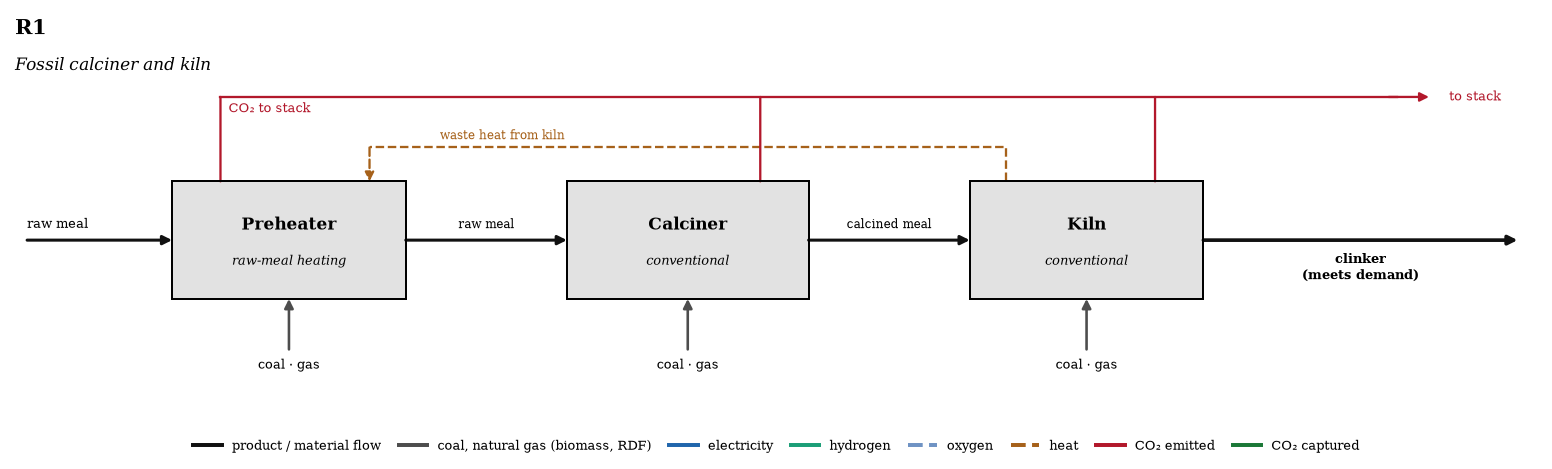

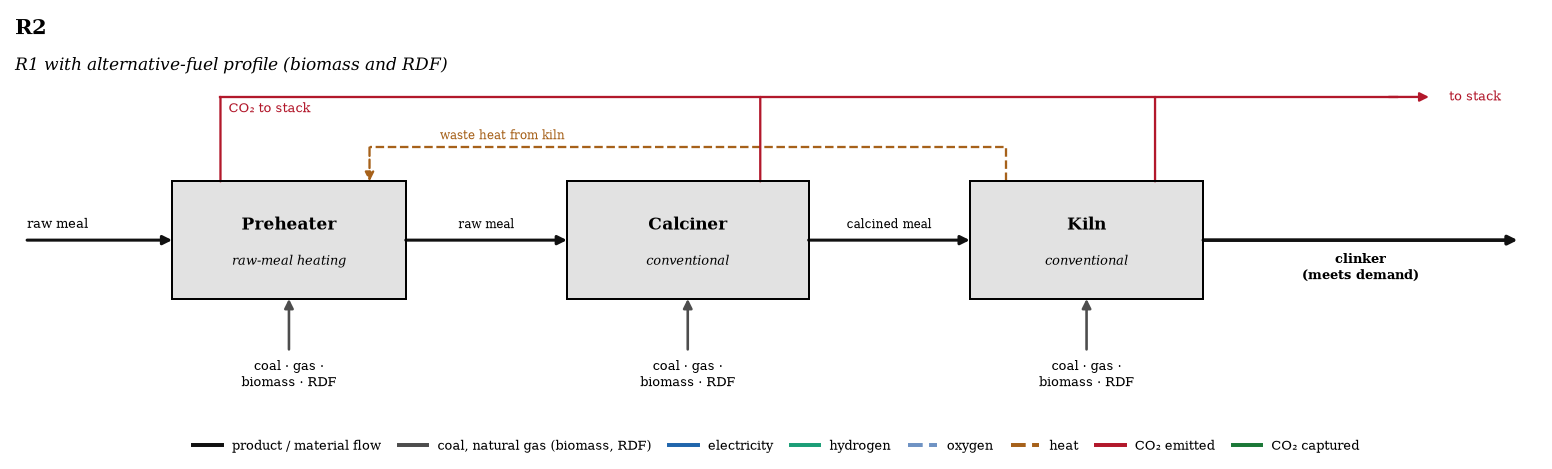

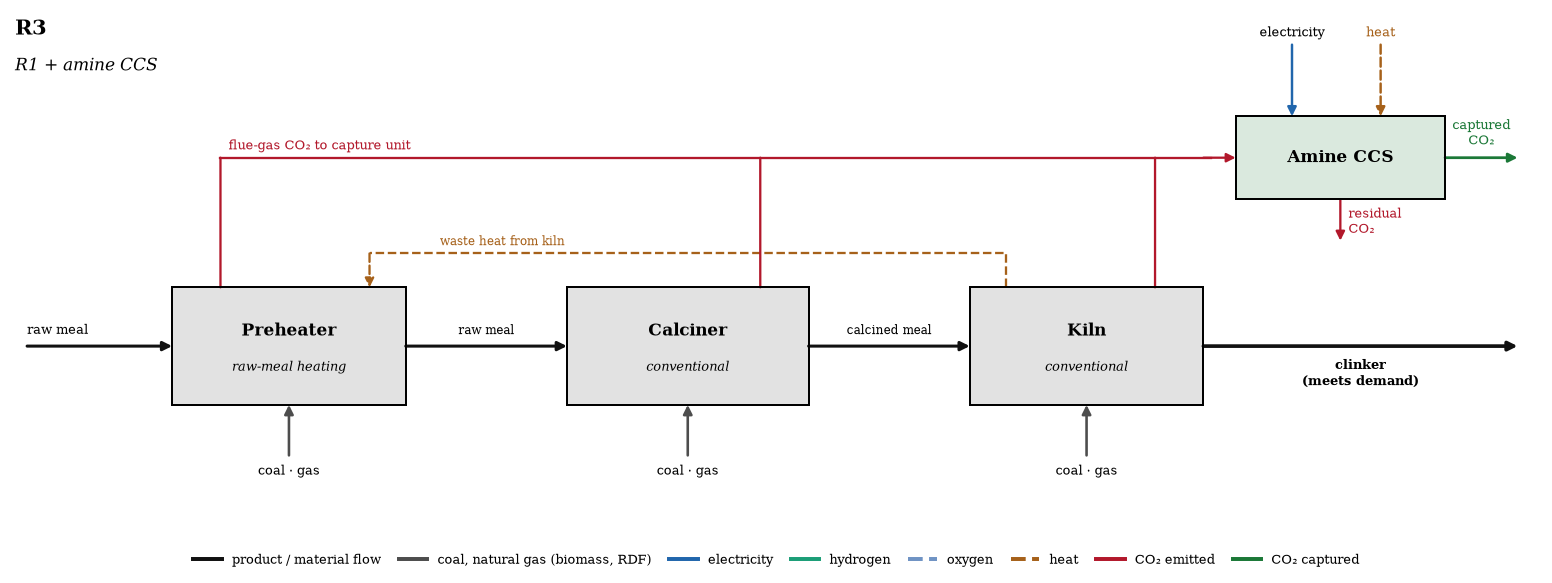

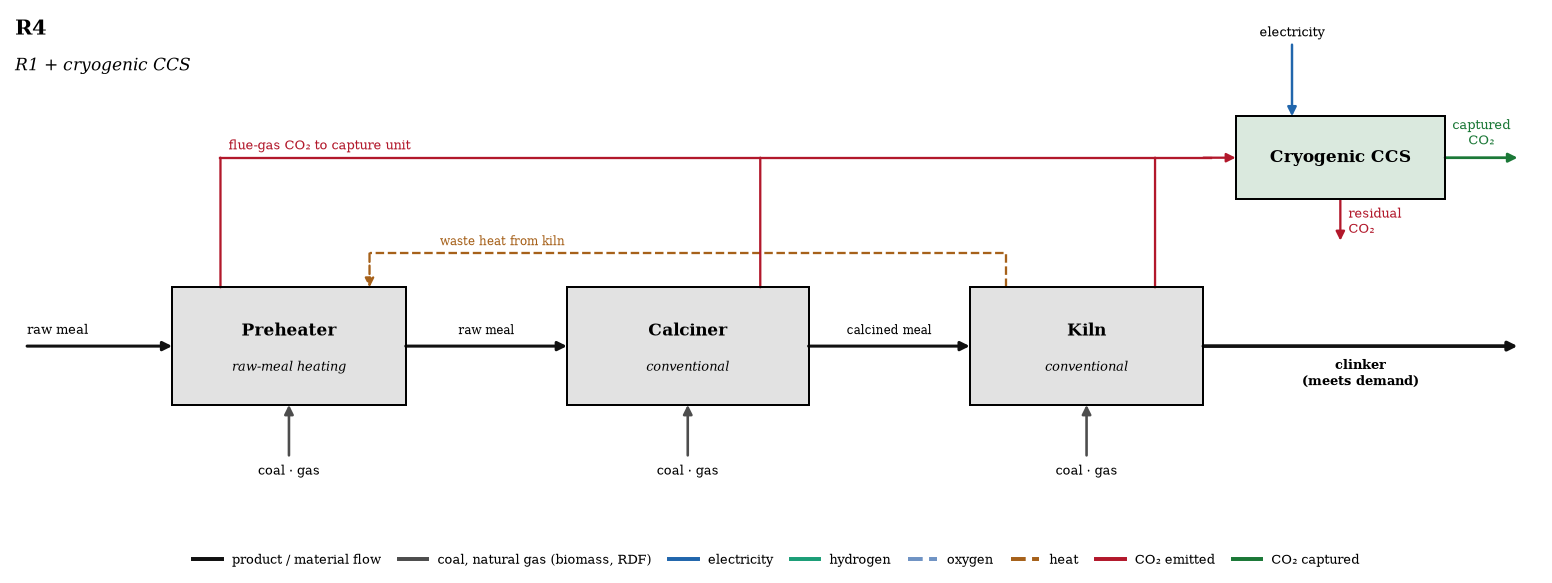

In [3]:
for r in ['R1', 'R2', 'R3', 'R4']:
    draw_cement(r, CEMENT_ROUTES[r])

### 2. Electrified routes (R5 to R8)

Electrifying a stage removes its fuel CO2 but not the calcination CO2, which stays with the calciner whatever its fuel. R5 heats the calciner electrically, R6 lets the optimiser mix electricity and fossil fuel in the calciner, R7 adds amine capture to R5. R8 is electric in all three stages, so the only CO2 left in the flue gas is the calcination CO2, which a cryogenic capture block removes.

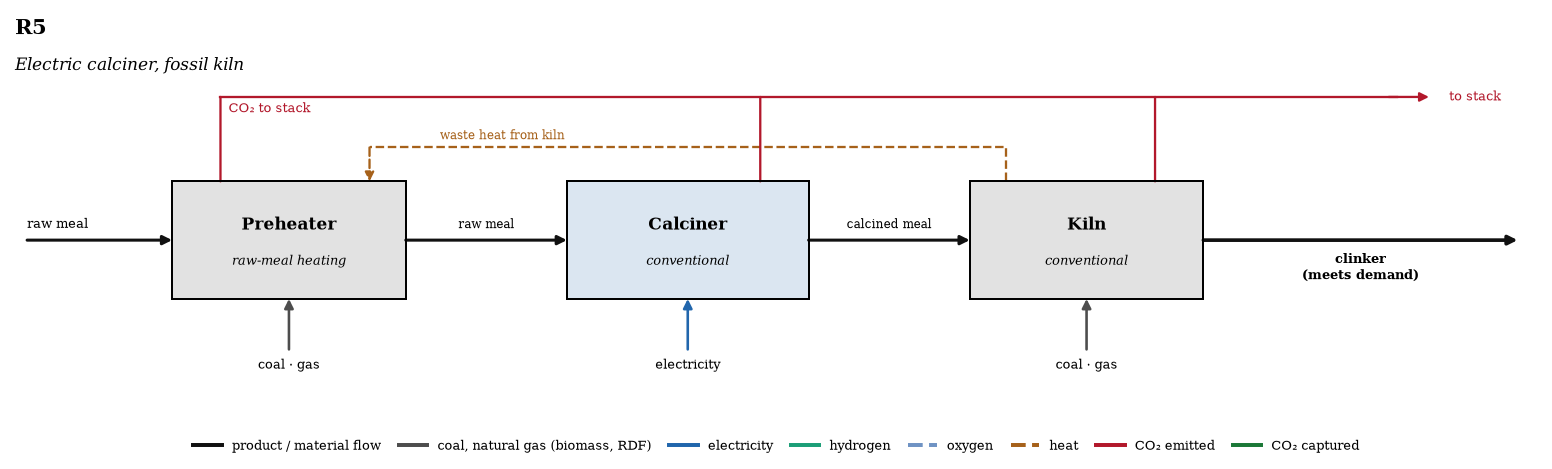

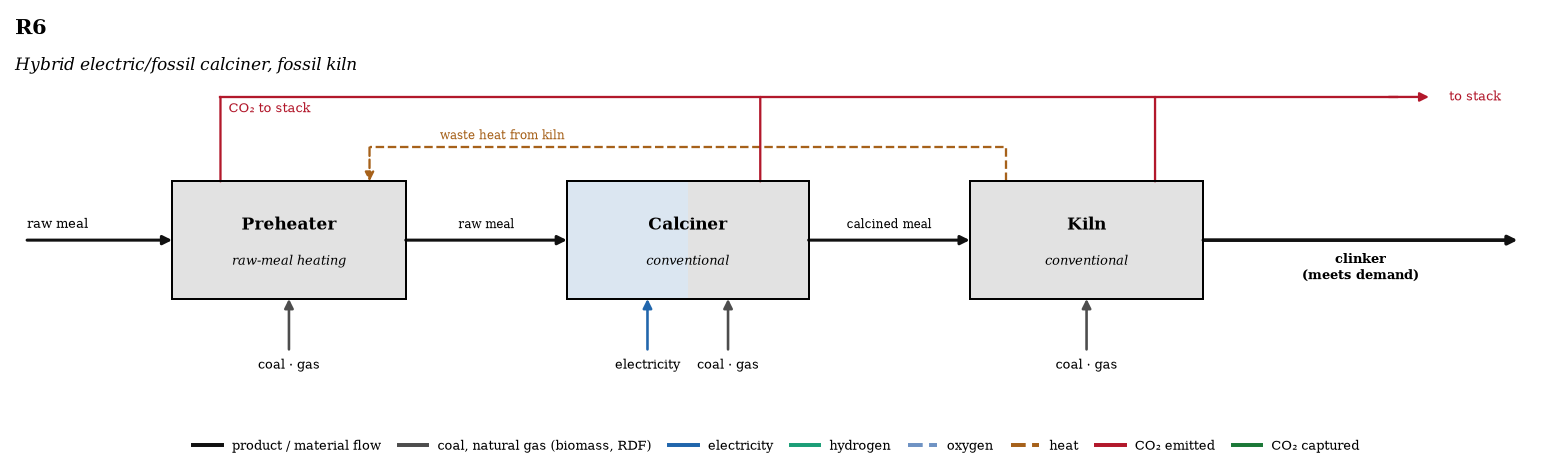

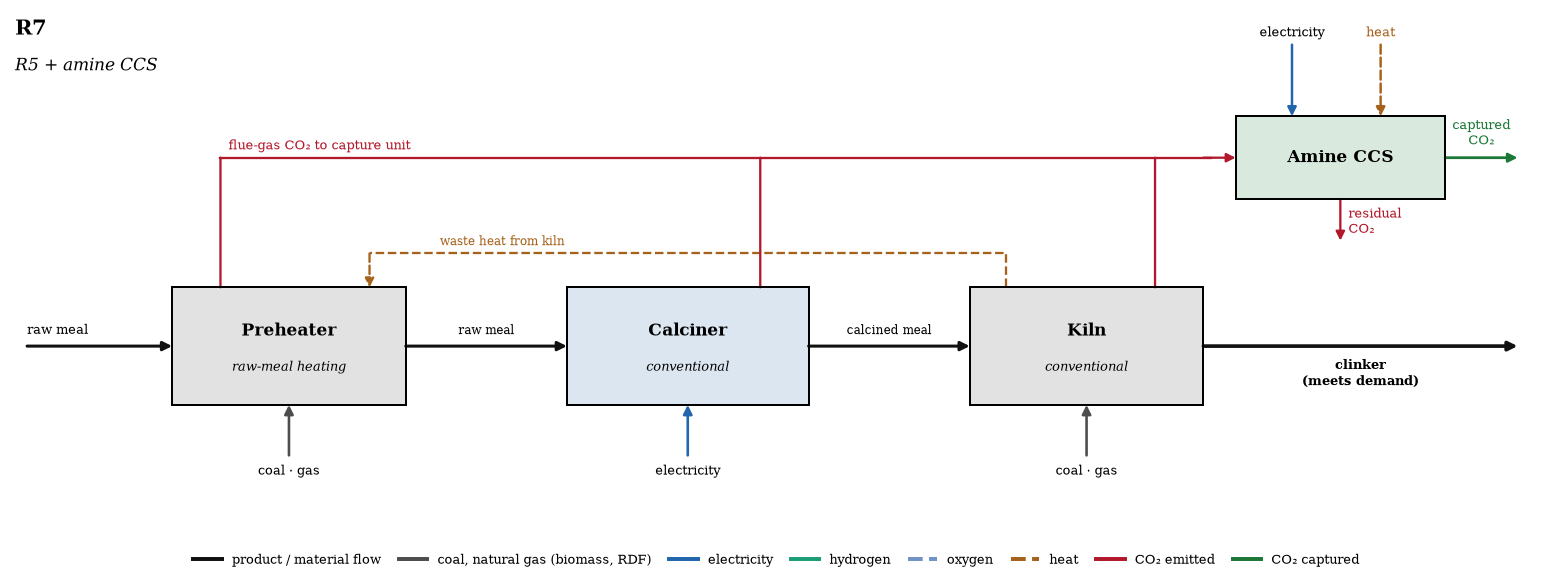

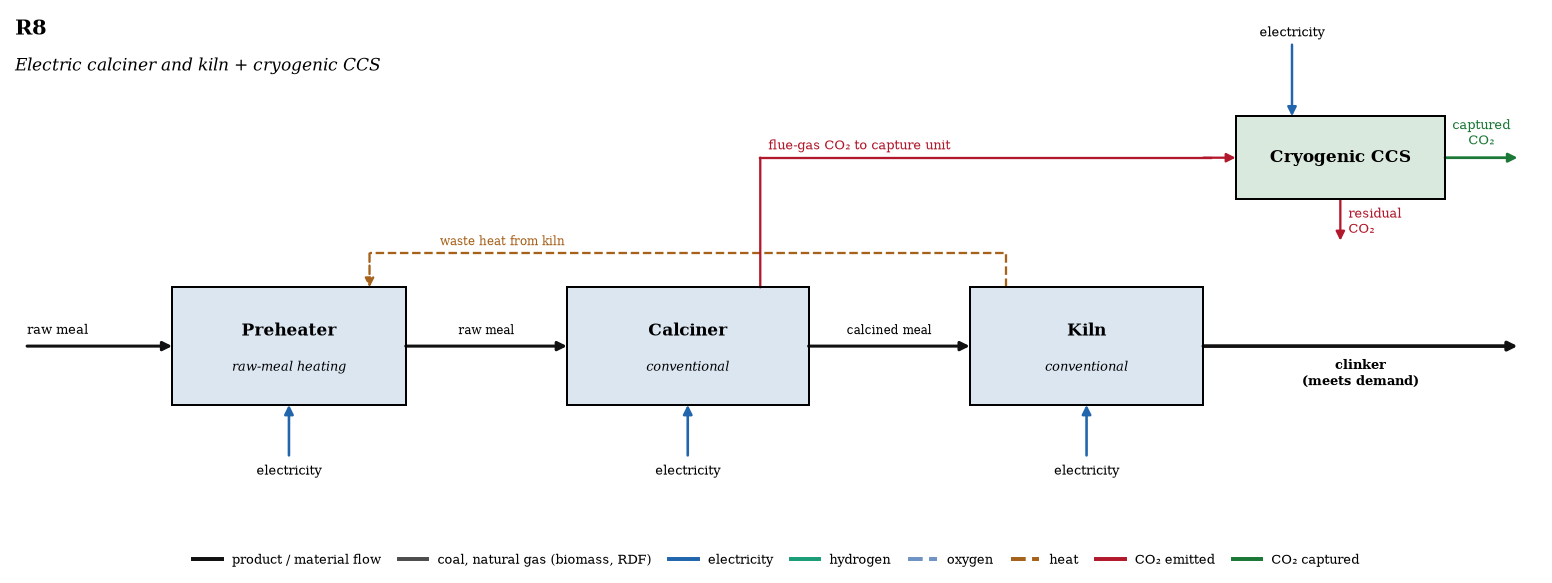

In [4]:
for r in ['R5', 'R6', 'R7', 'R8']:
    draw_cement(r, CEMENT_ROUTES[r])

### 3. Oxyfuel routes (R9, R10, R12a, R12b)

In an oxyfuel stage the fuel burns in oxygen, so the flue gas is nearly pure CO2. The oxygen demand follows from the fuel burned. Where an electrolyser exists (R12b), its co-product oxygen covers part of the demand; the remainder is generated inside the stage with electricity (there is no separate air-separation block). The recovery block receives **only the flue gas of oxyfuel stages**: in R10 the kiln is conventional and in all four routes the preheater is air-fired, so their CO2 bypasses the recovery block and goes to the stack. The recovery block draws electricity only.

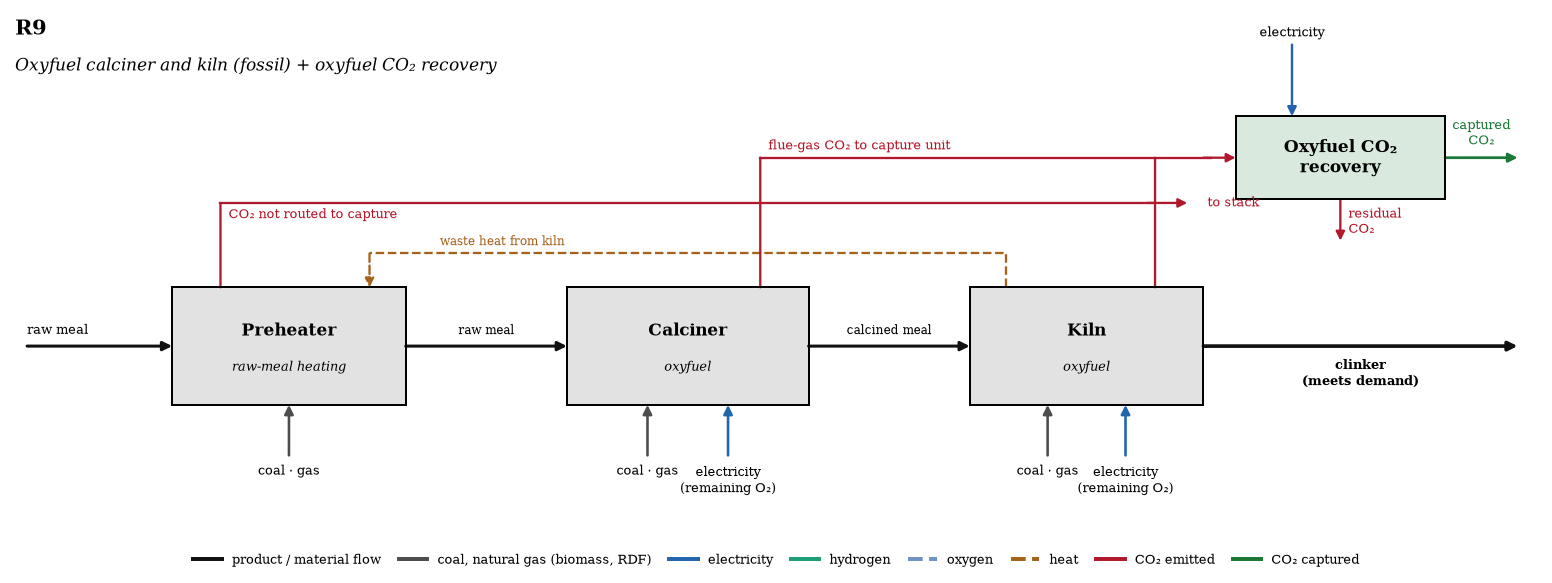

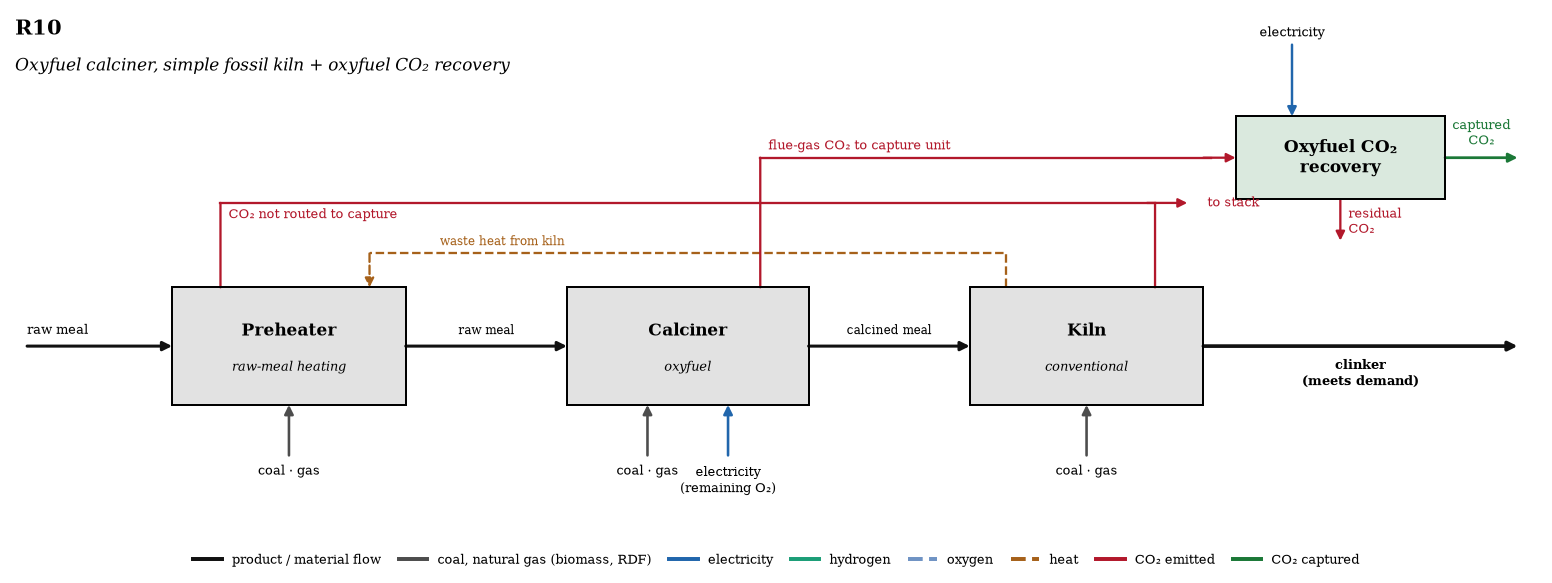

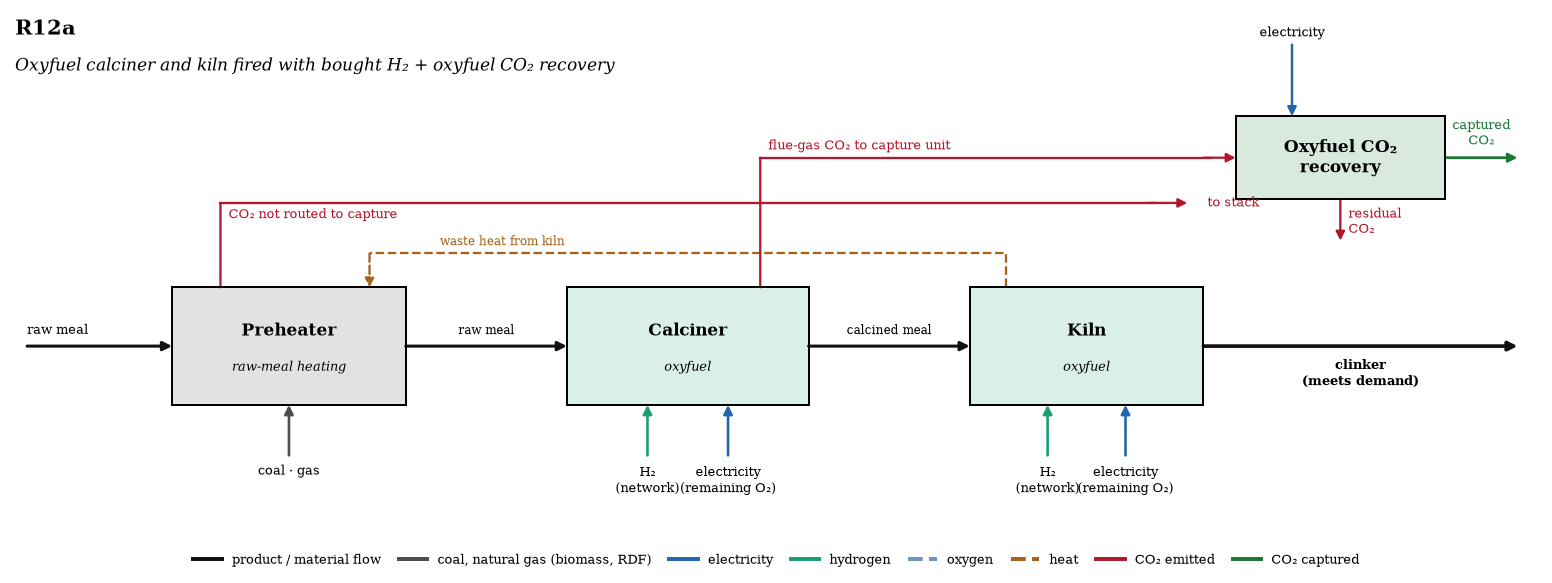

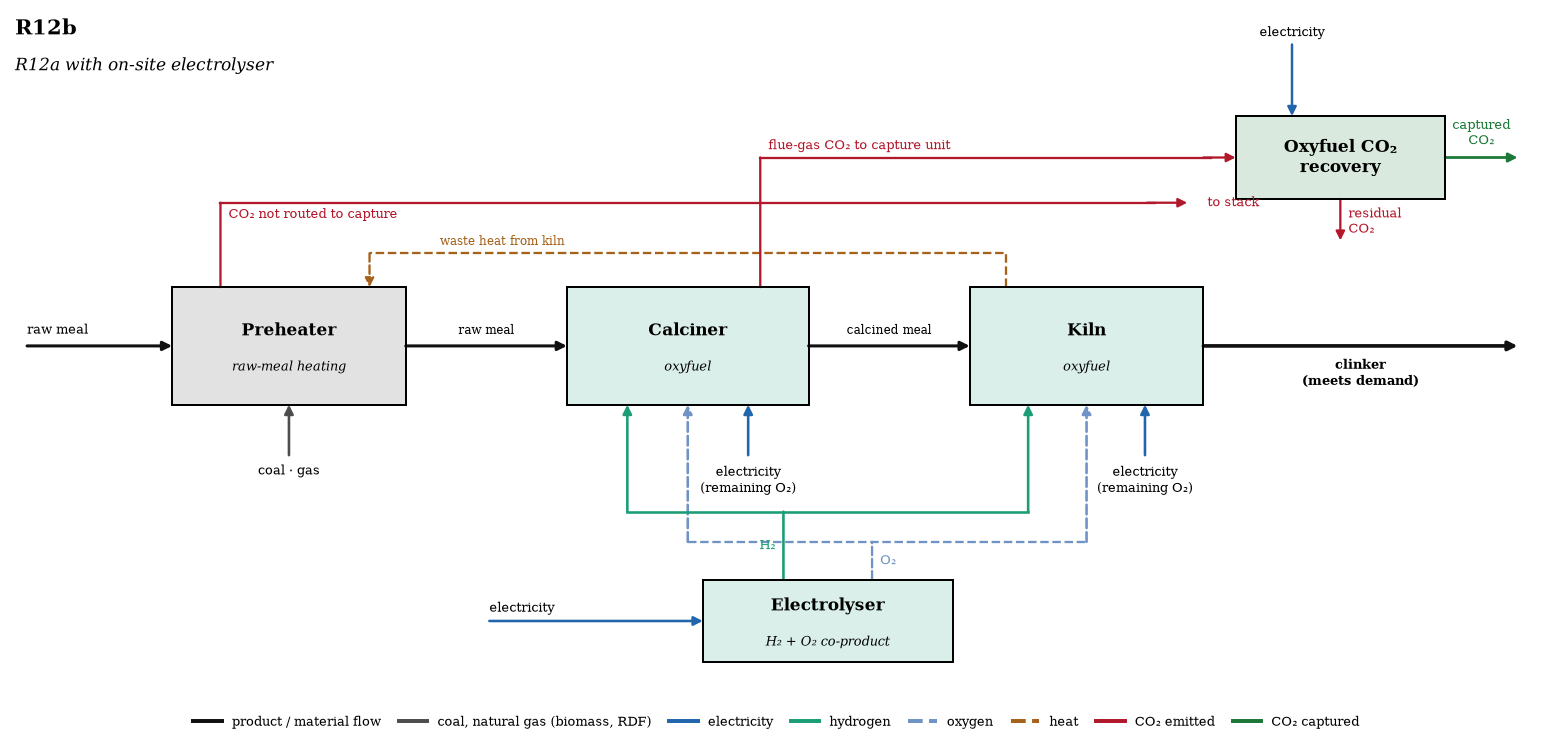

In [5]:
for r in ['R9', 'R10', 'R12a', 'R12b']:
    draw_cement(r, CEMENT_ROUTES[r])

### 4. Hydrogen-fired routes (R11a, R11b)

Calciner and kiln run on hydrogen only, so they emit no fuel CO2; the calciner still emits calcination CO2. The **preheater stays fossil-fired**, which is why these routes still show a few percent coal in the energy mix. Amine capture treats the flue gas of preheater, calciner and kiln. In R11b an on-site electrolyser supplies exactly the hydrogen that calciner and kiln demand; its electricity is an additional input.

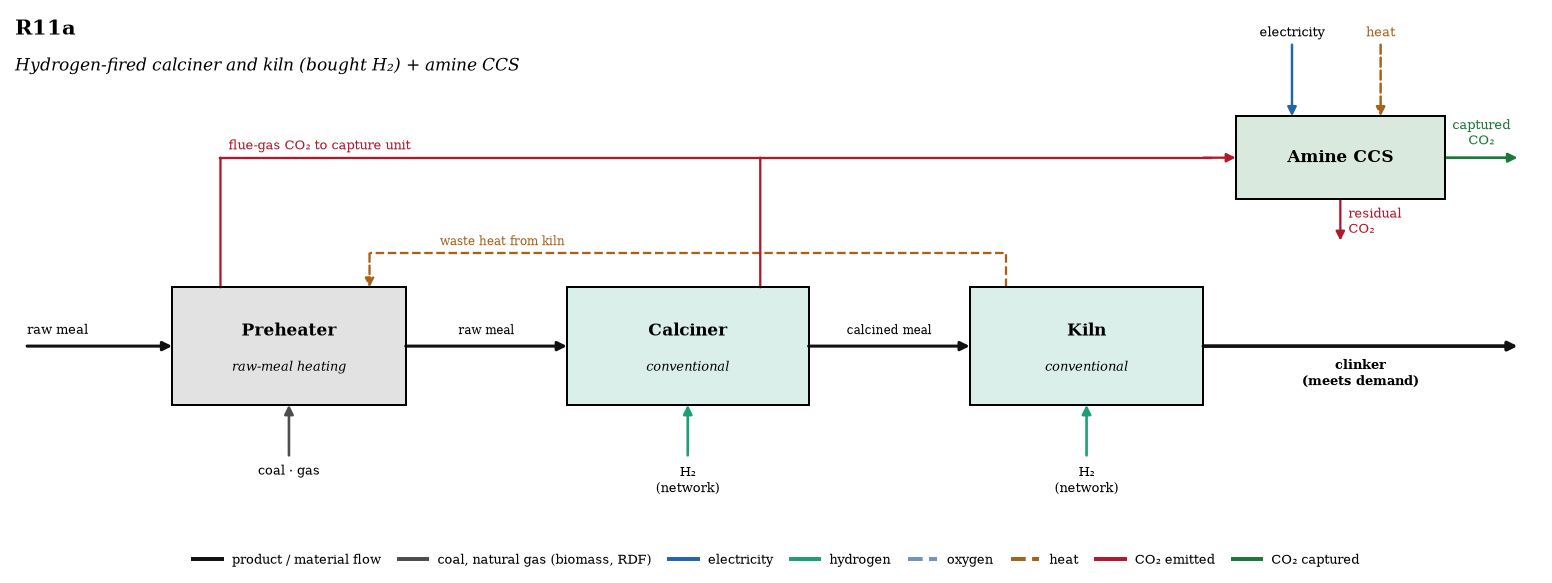

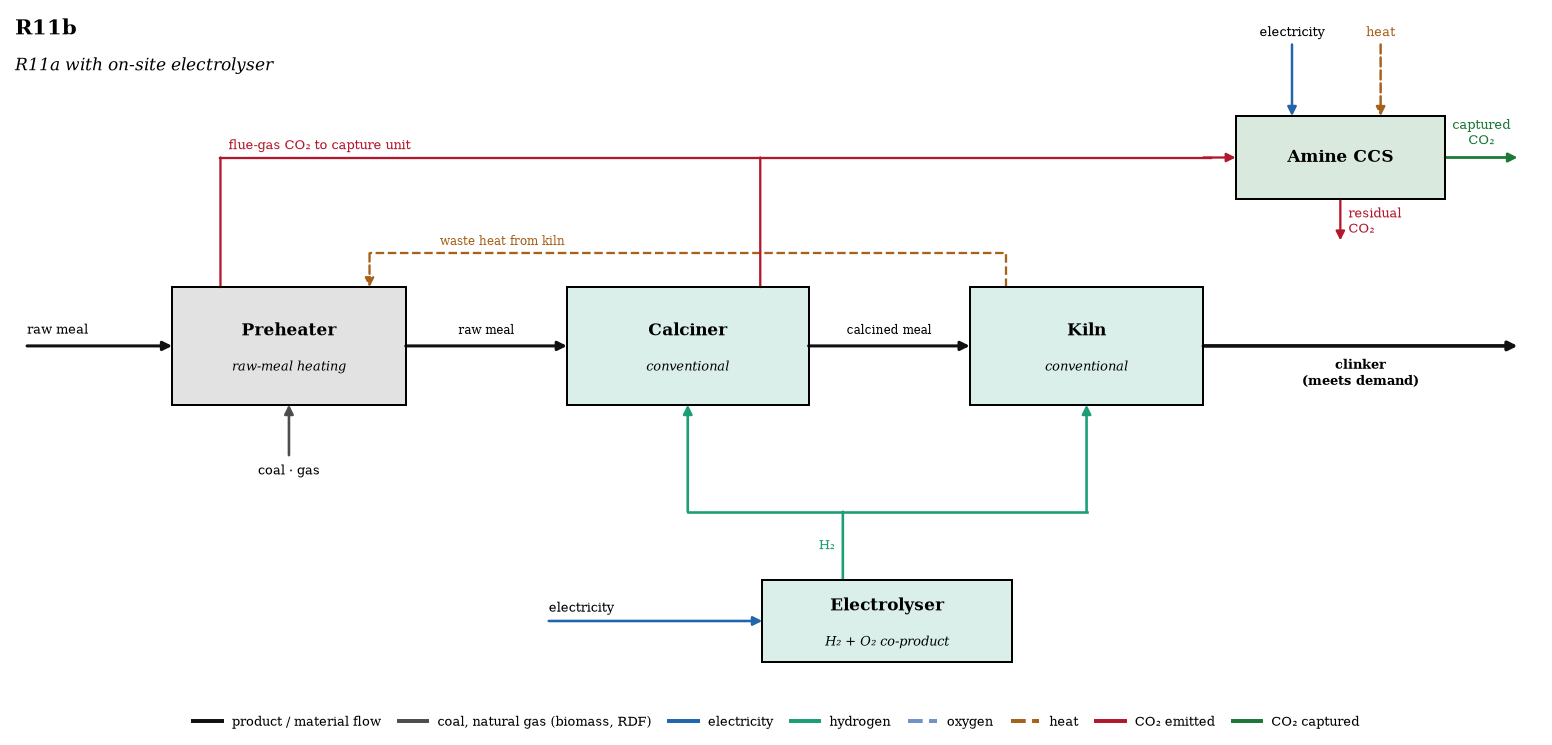

In [6]:
for r in ['R11a', 'R11b']:
    draw_cement(r, CEMENT_ROUTES[r])

### 5. LEILAC routes (R13 to R16)

The LEILAC calciner is heated indirectly, which keeps the calcination CO2 in a separate stream. The model separates a configured fraction of the calcination CO2 directly (green arrow, no capture unit); the residual calcination CO2 and all combustion CO2 stay in the flue gas. R13 uses fossil fuel, R14 electricity, R15a and R15b hydrogen (bought, respectively from an on-site electrolyser). R16 adds an amine capture block for the remaining CO2.

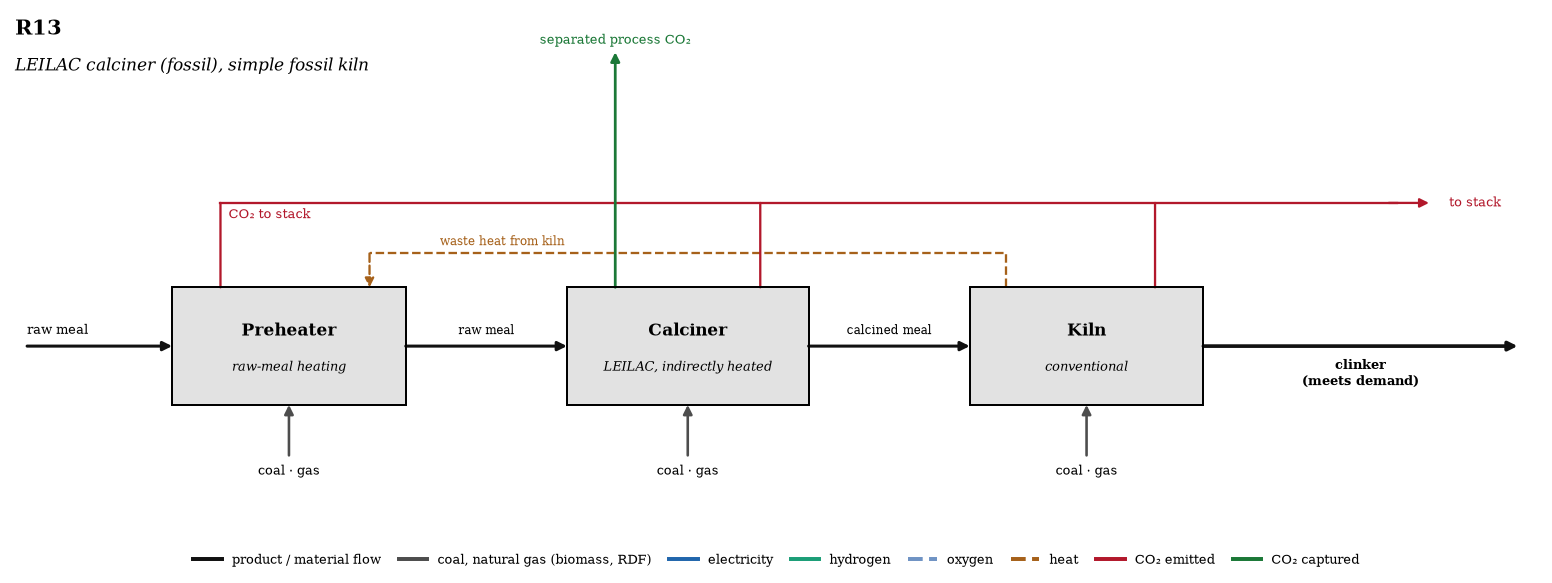

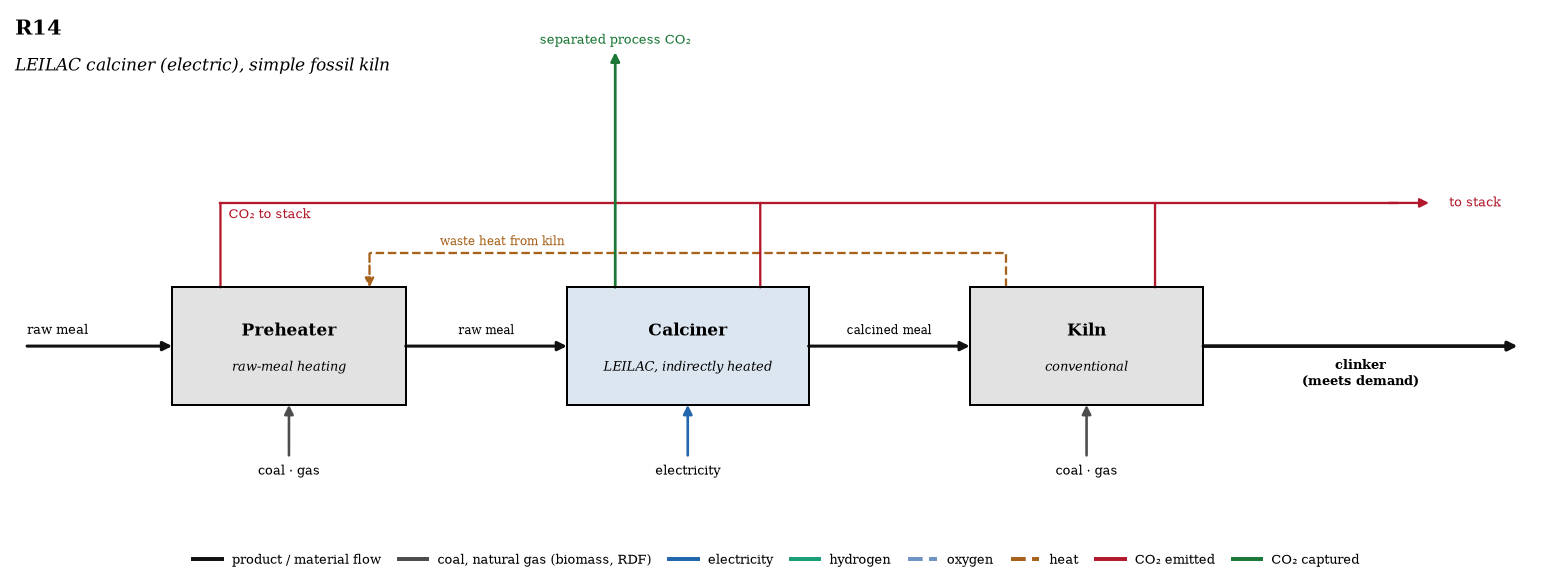

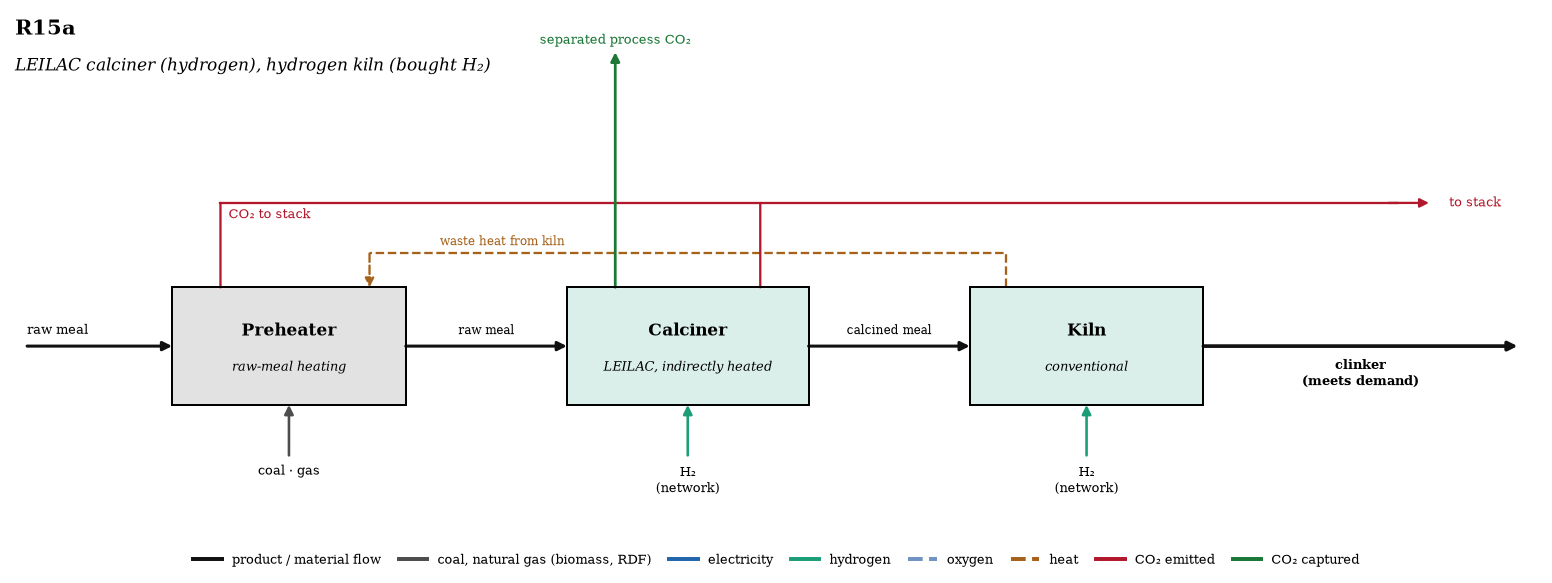

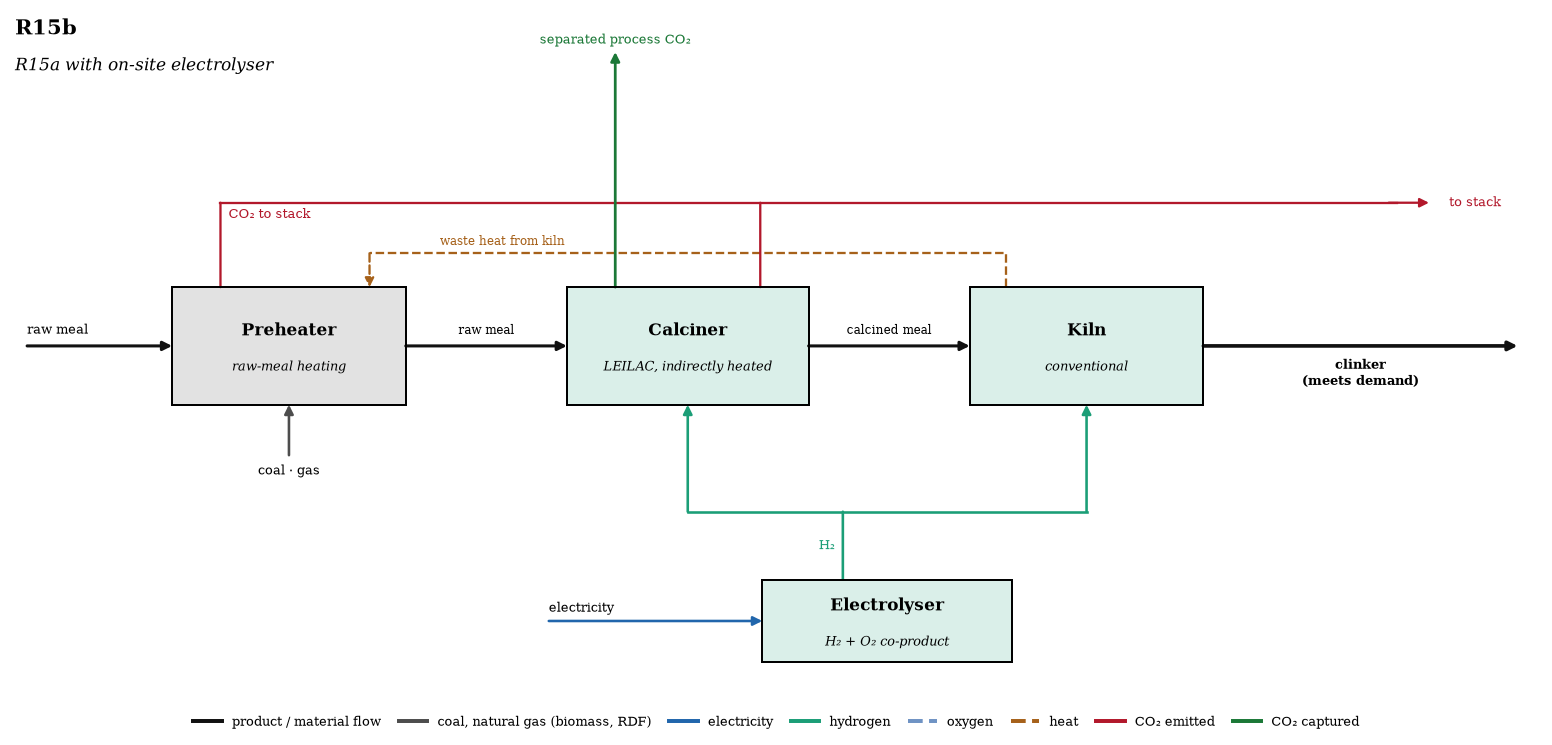

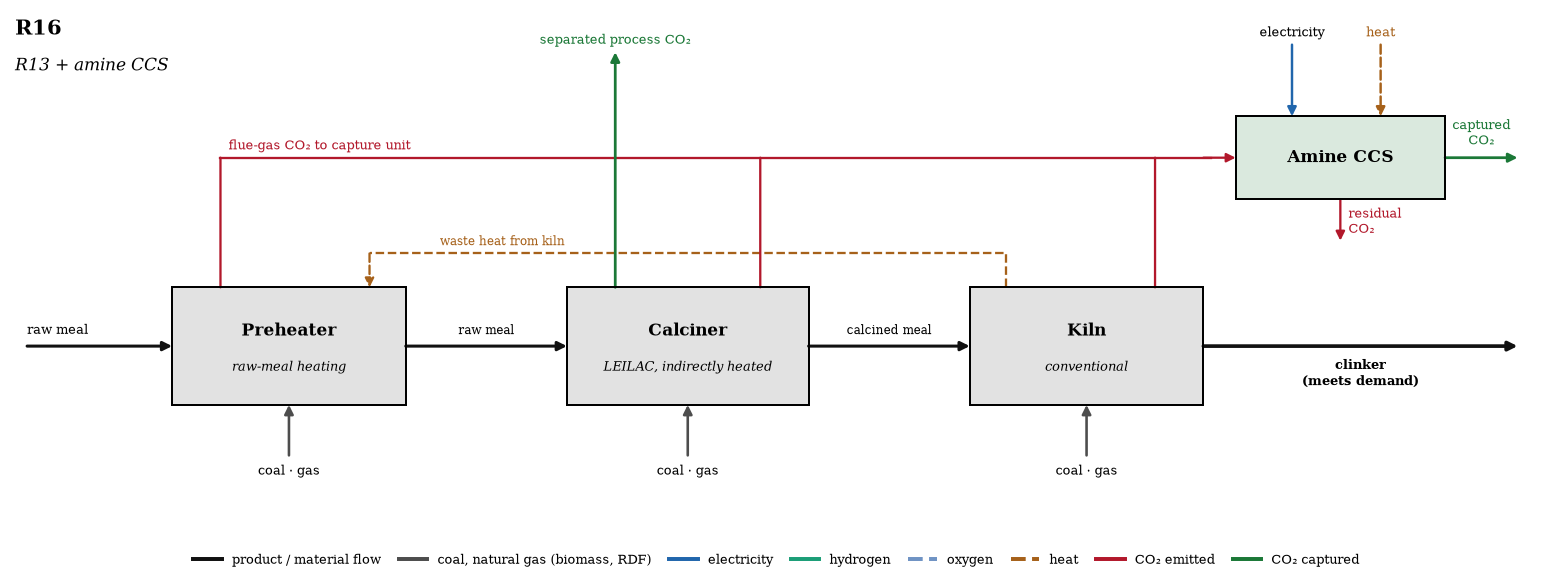

In [7]:
for r in ['R13', 'R14', 'R15a', 'R15b', 'R16']:
    draw_cement(r, CEMENT_ROUTES[r])

## Steel

A steel configuration is a physical route (BF-BOF as one block, or a DRI shaft followed by an EAF or a BOF), a reducing fuel and a hydrogen supply. Per figure the same six variants appear: coal, natural gas, hydrogen from the network, hybrid hydrogen plus gas from the network, and the two hydrogen variants with an on-site electrolyser. Coal and gas variants exist only with external supply because they need no hydrogen.

* The reduction stage (DRI shaft or BF-BOF block) takes the reducing fuel, electricity and iron ore. Fuel CO2 arises there if the fuel is coal or natural gas.
* The converter (EAF, BOF; inside the block for BF-BOF) takes DRI, electricity and lime. Lime releases CO2 in every configuration, so even the hydrogen routes emit a little.
* With the hybrid fuel the optimiser chooses gas, hydrogen or a mix from the prices; hydrogen displaces gas one for one on a reduction-demand basis.

### BF-BOF: blast furnace and basic oxygen furnace

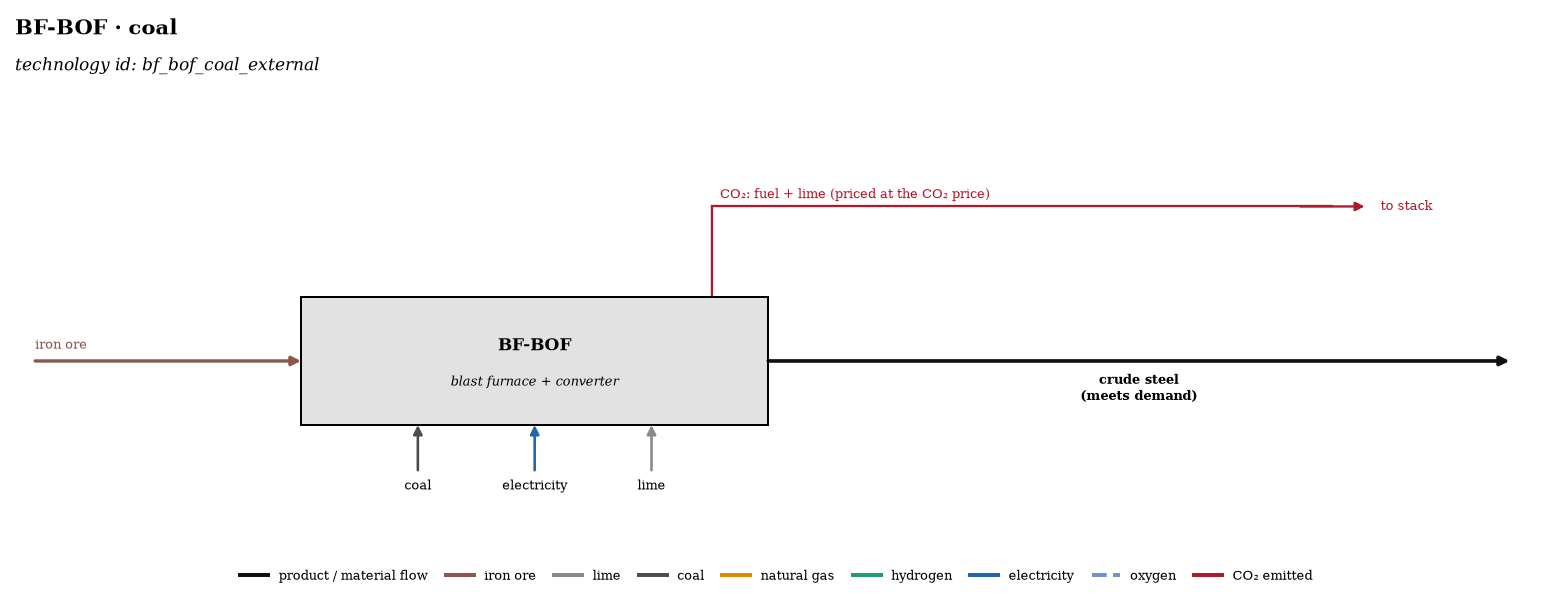

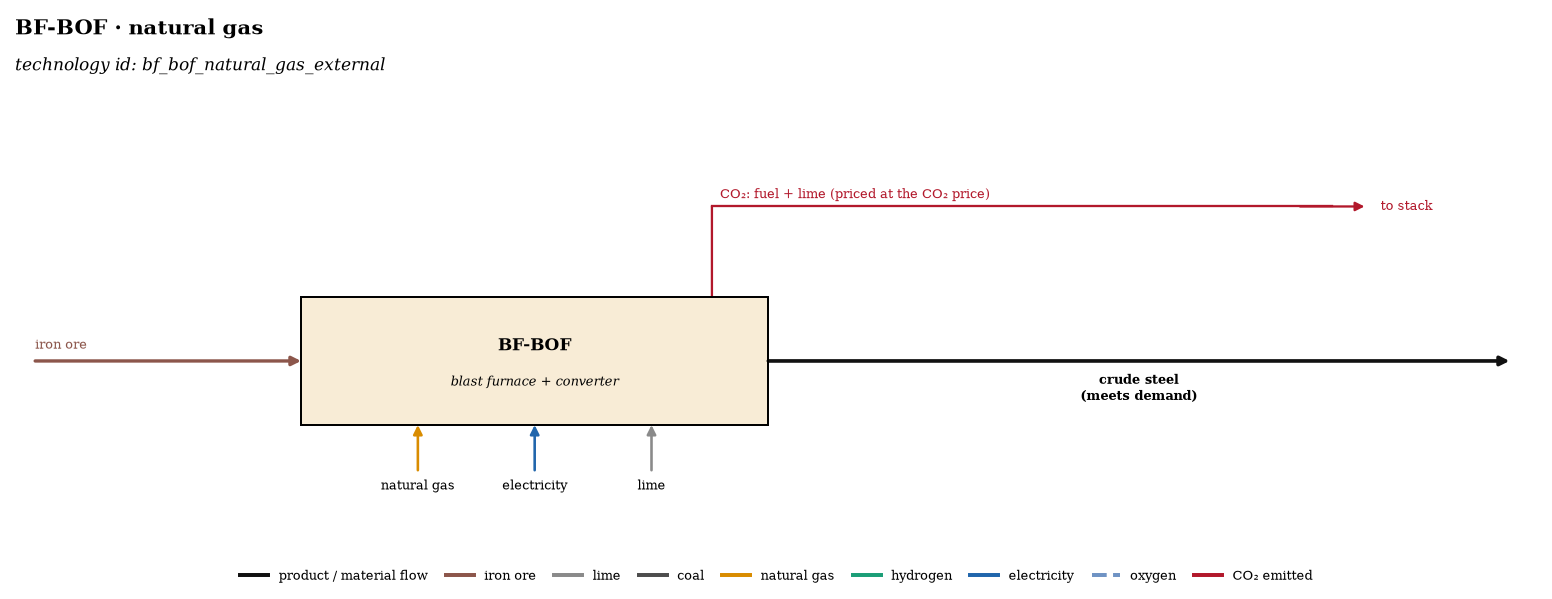

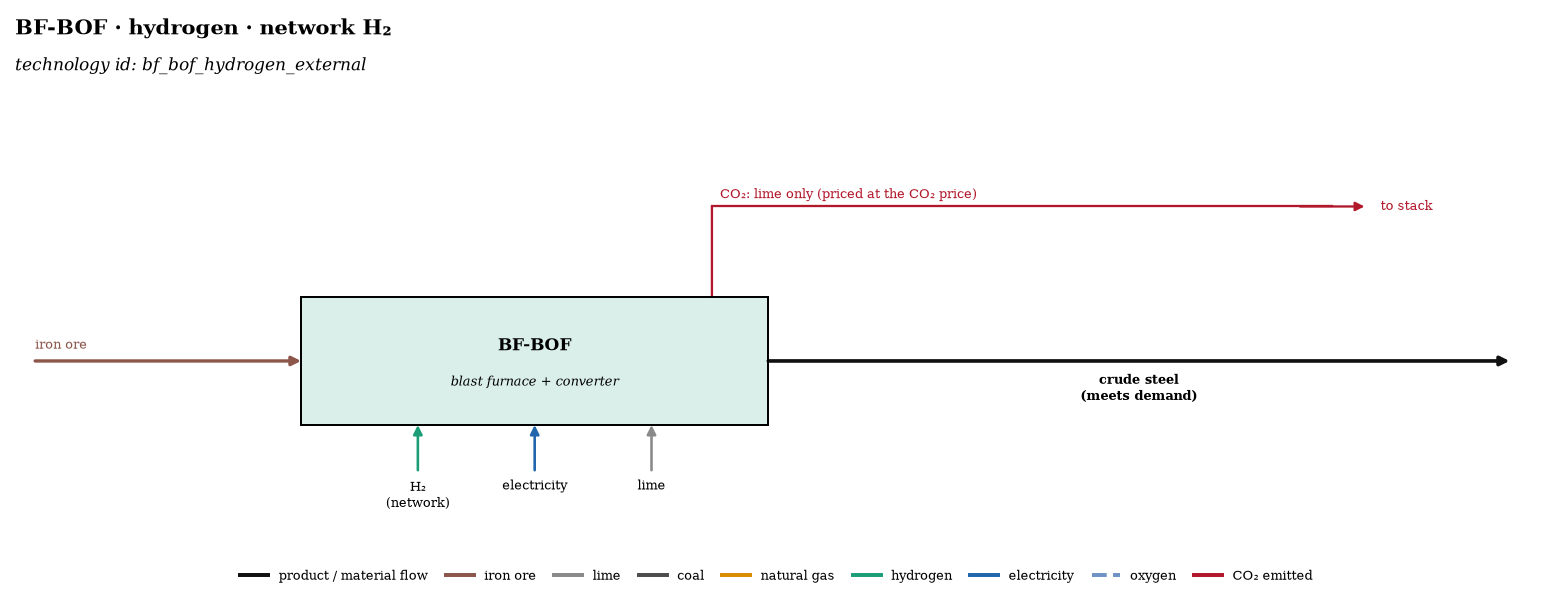

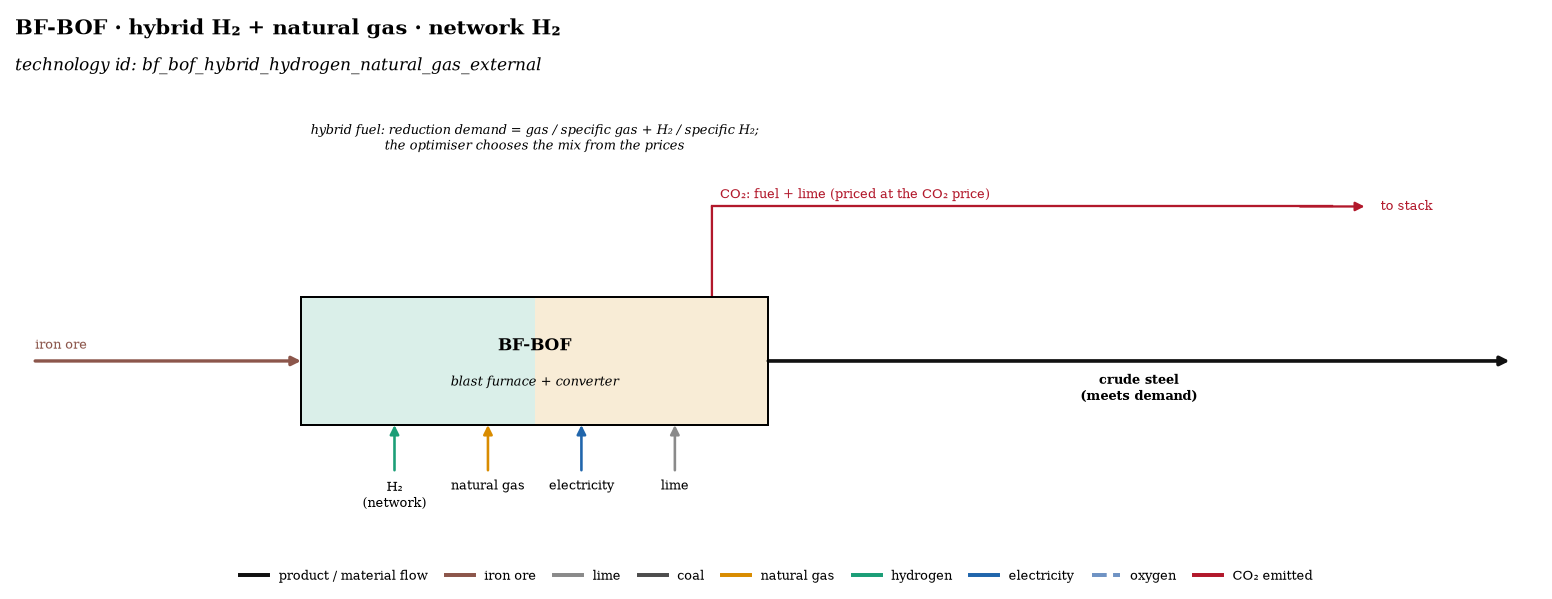

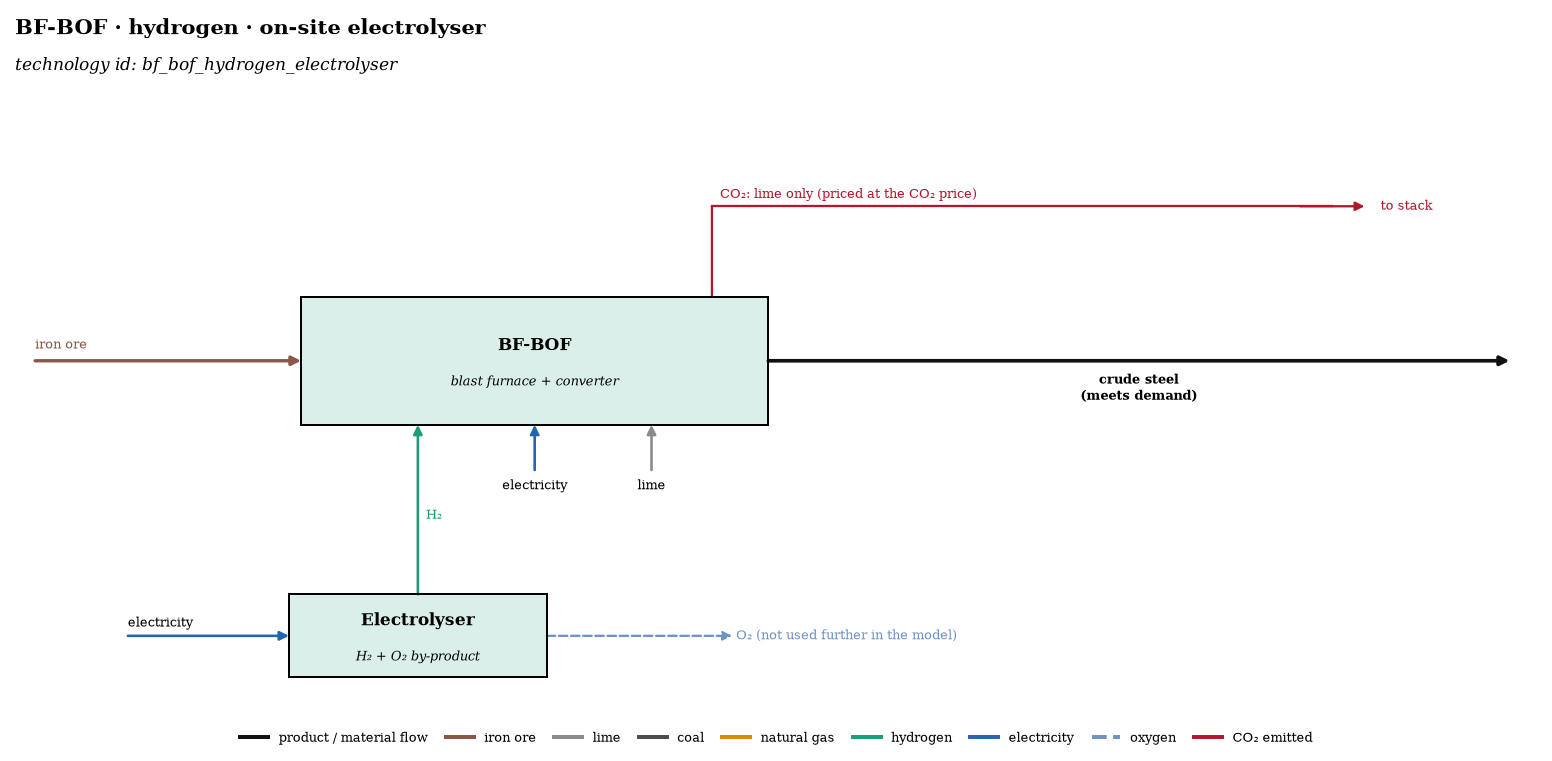

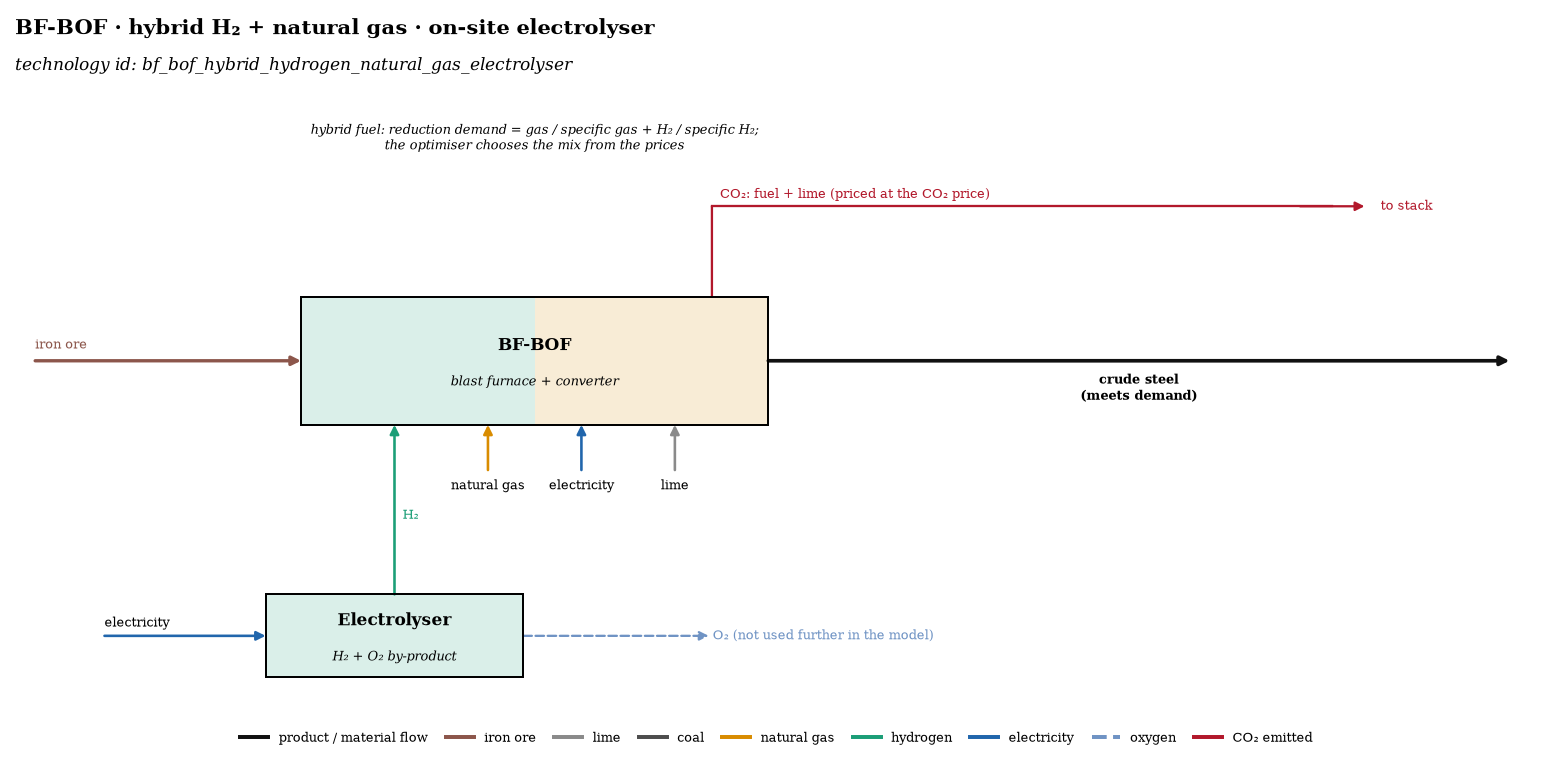

In [8]:
for fuel, supply in STEEL_ORDER:
    draw_steel_config('bf_bof', fuel, supply)

### DRI-BOF: direct reduction and basic oxygen furnace

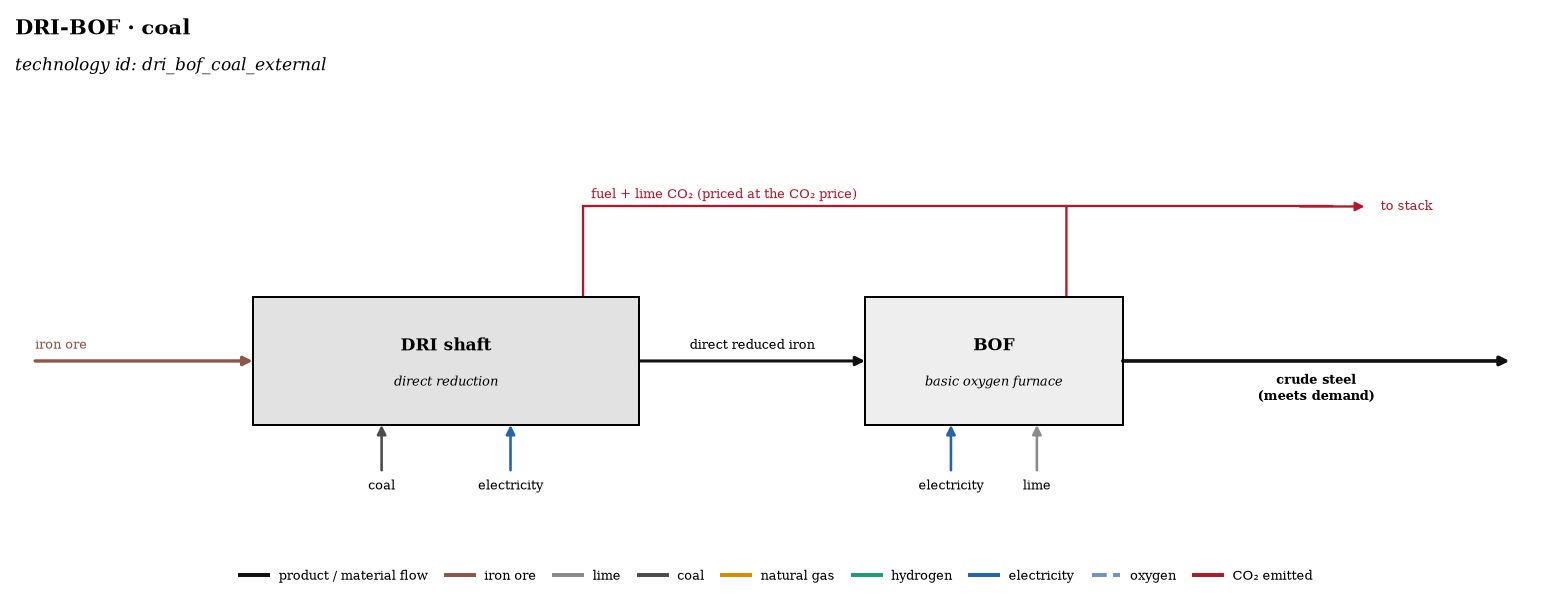

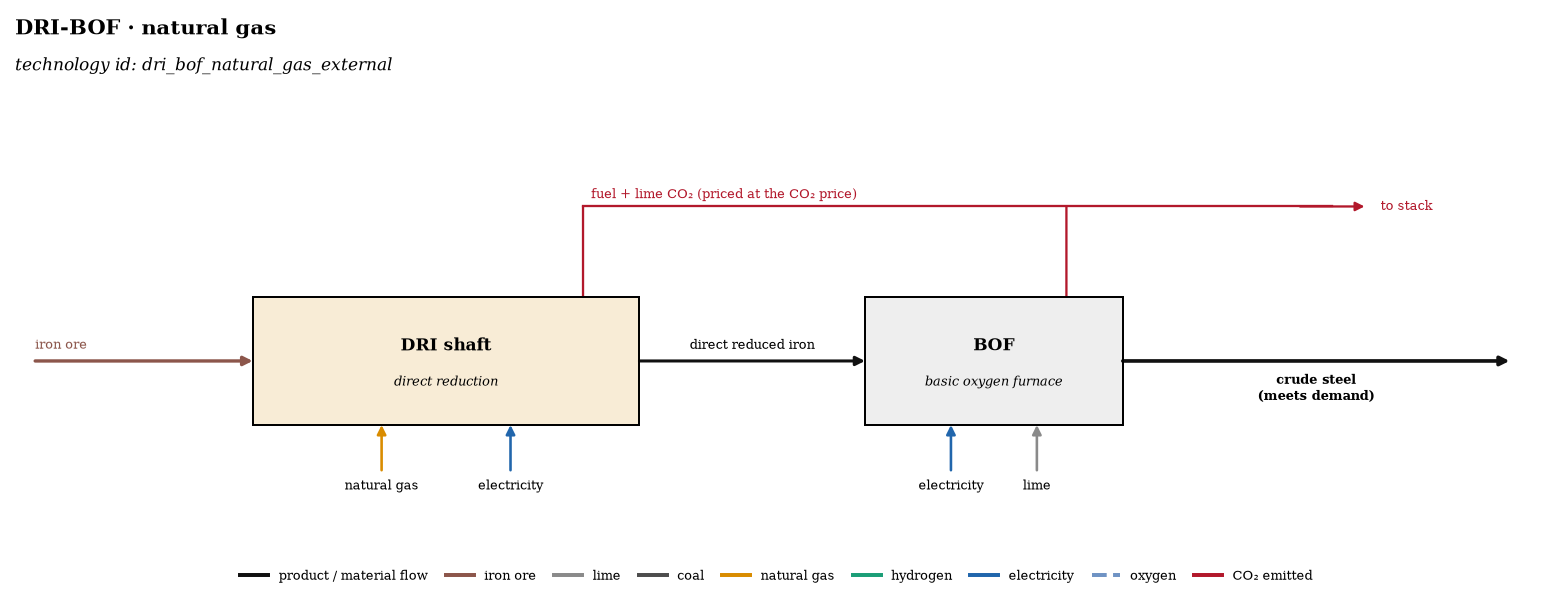

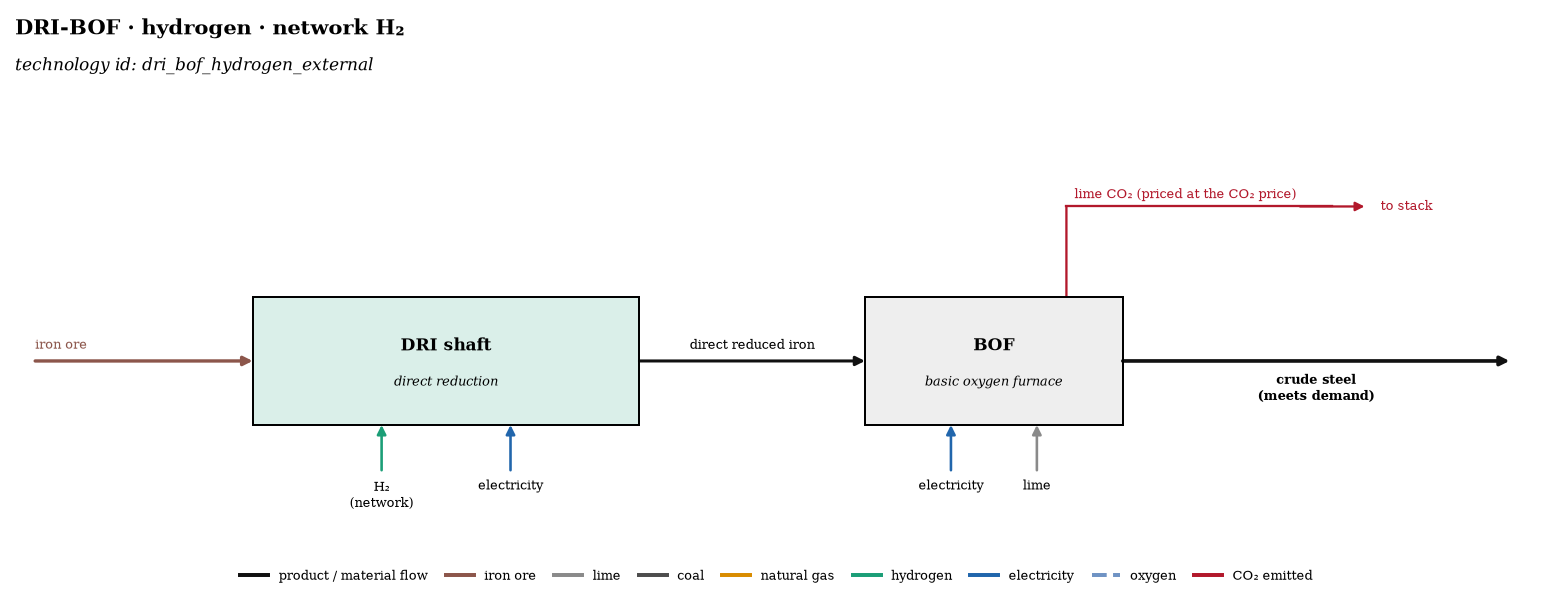

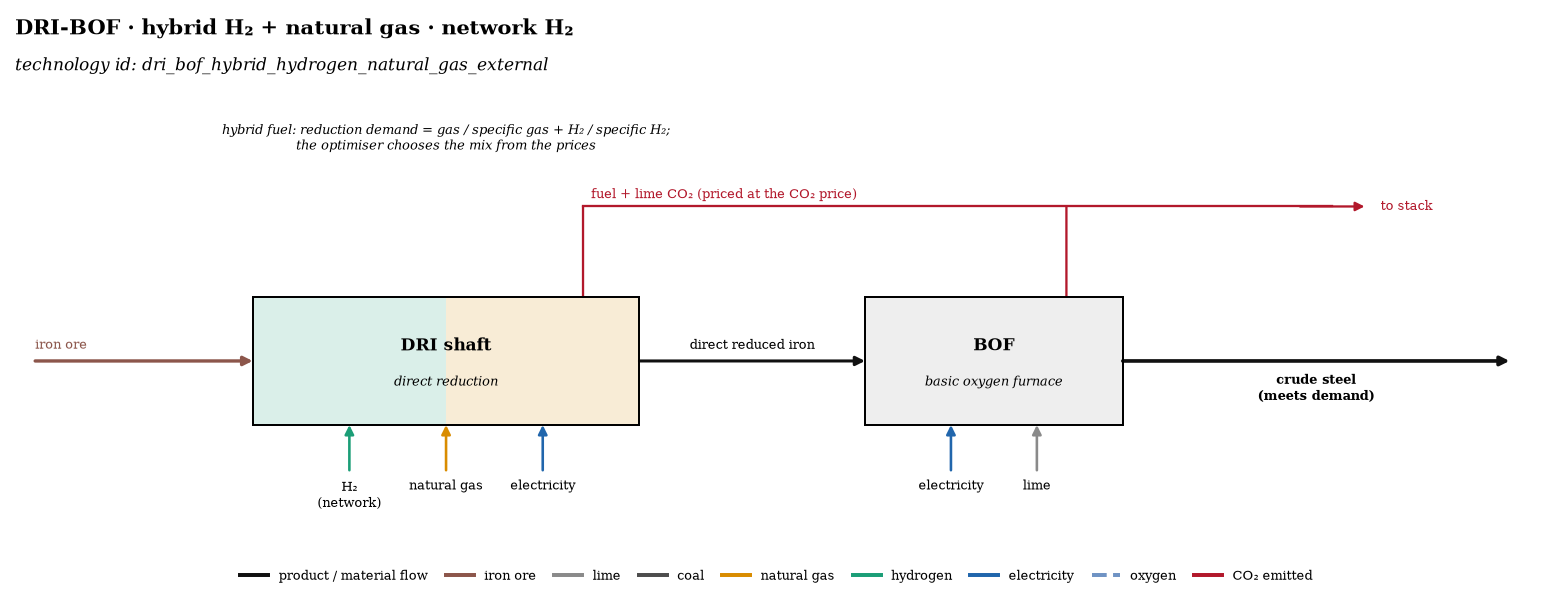

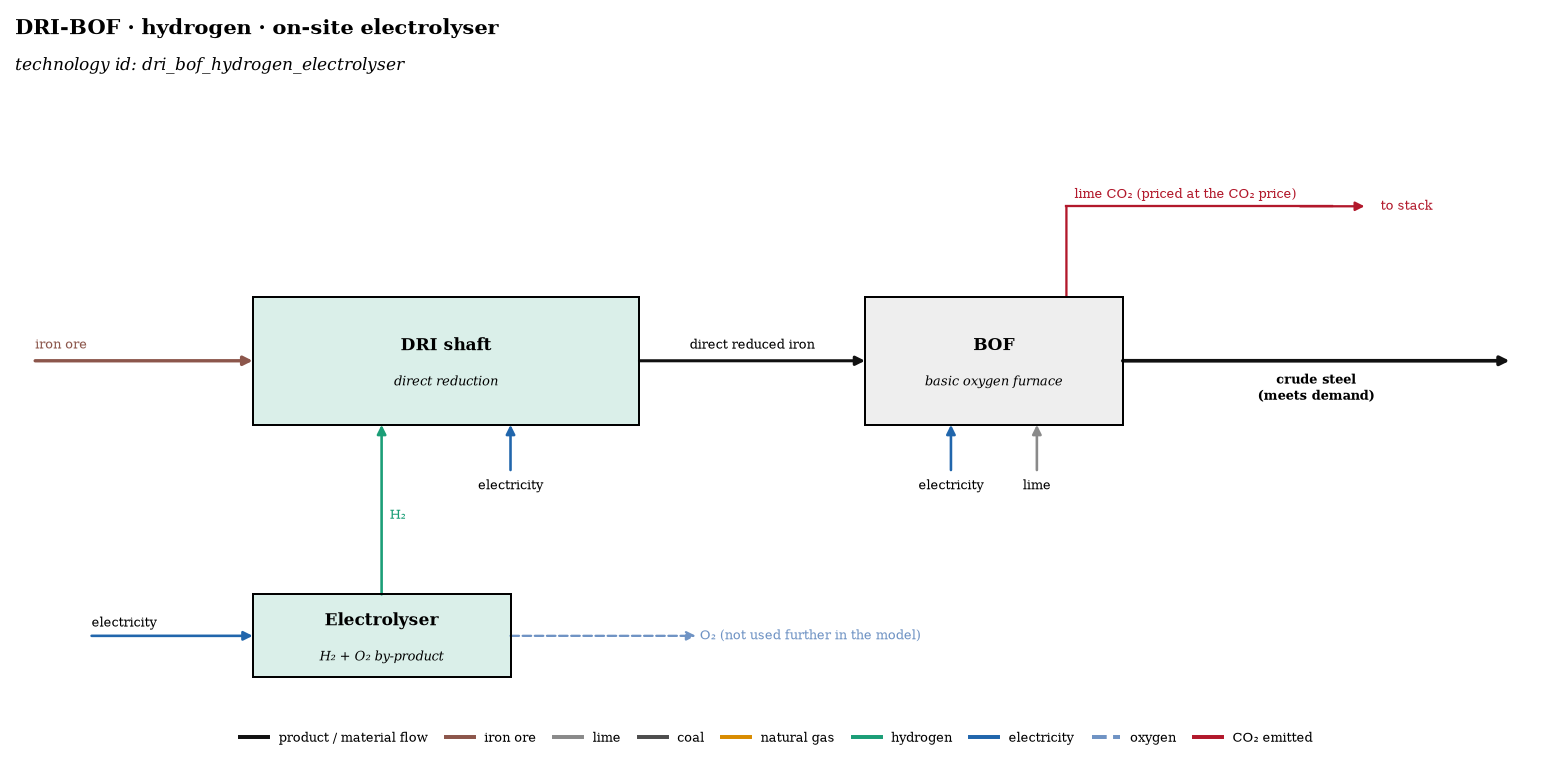

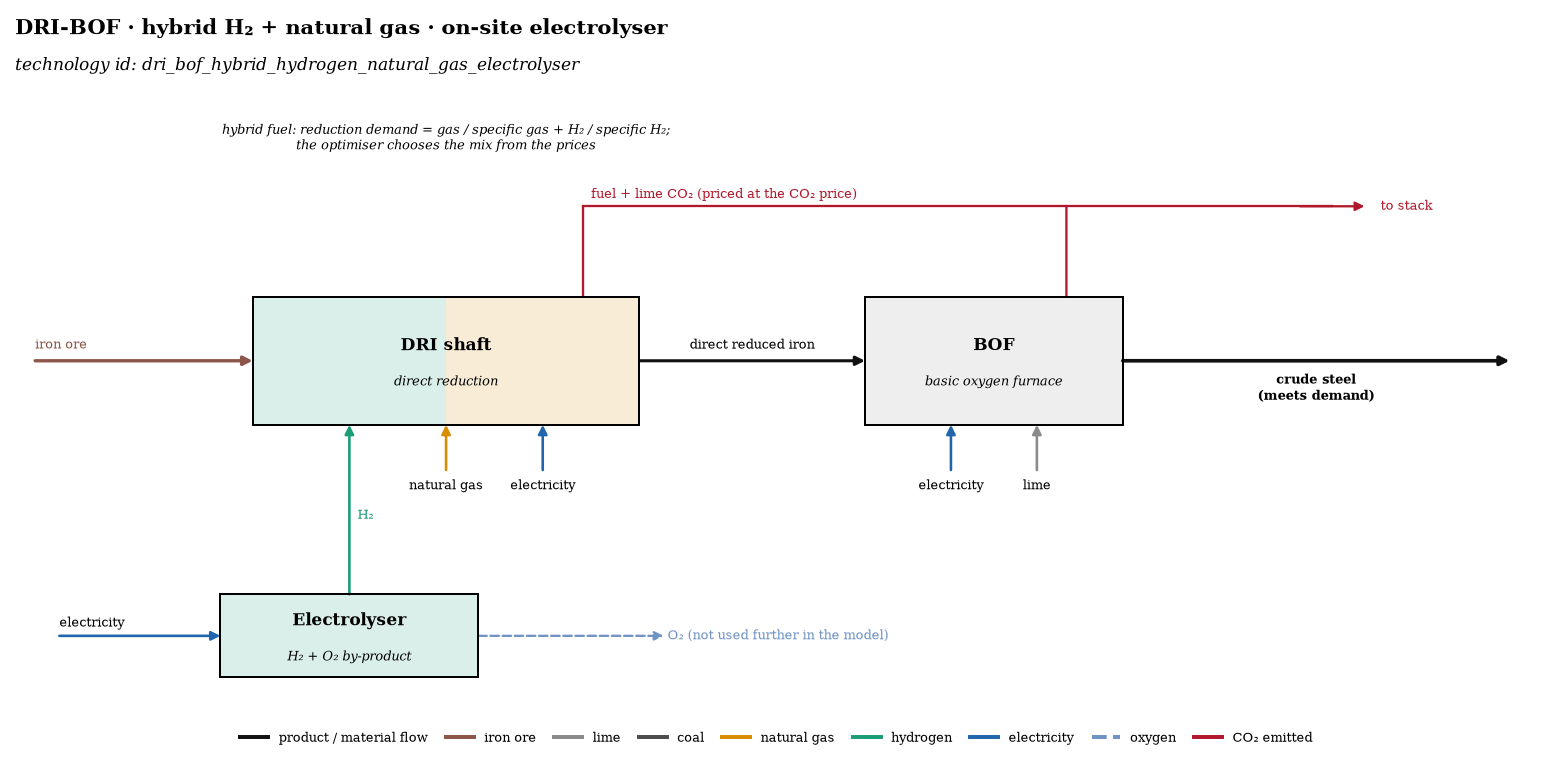

In [9]:
for fuel, supply in STEEL_ORDER:
    draw_steel_config('dri_bof', fuel, supply)

### DRI-EAF: direct reduction and electric arc furnace

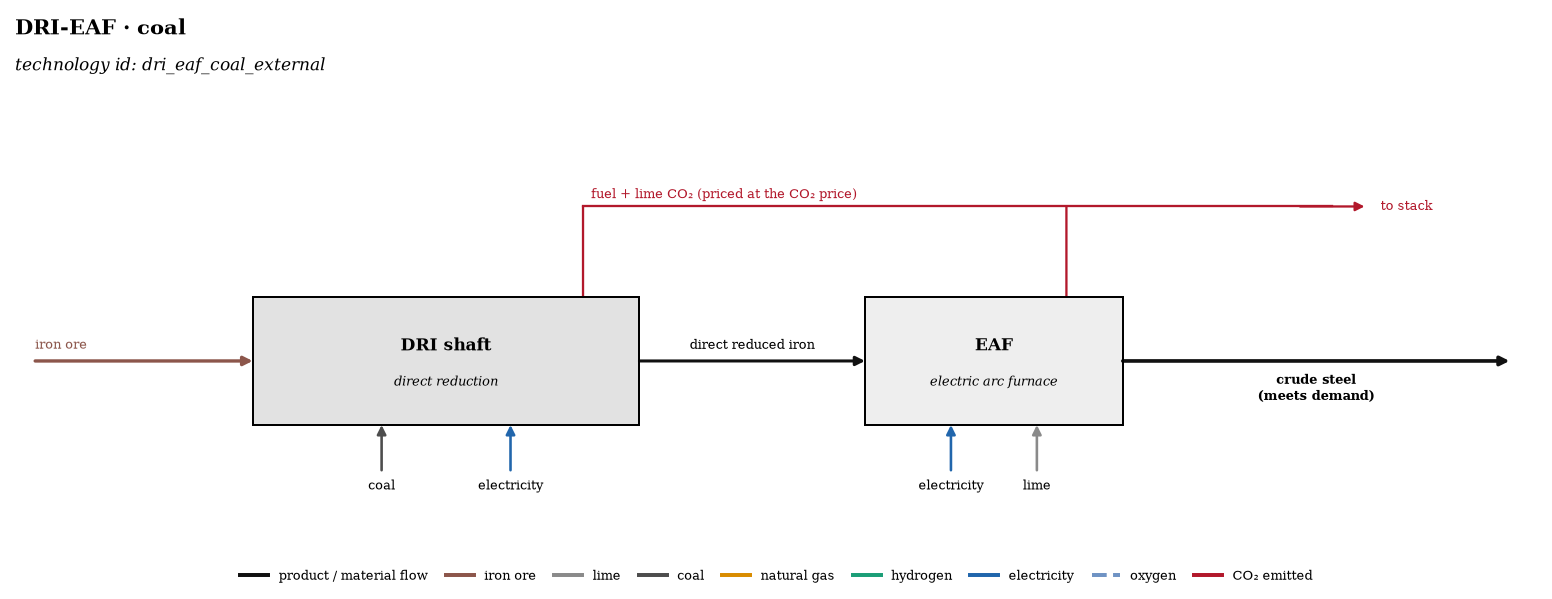

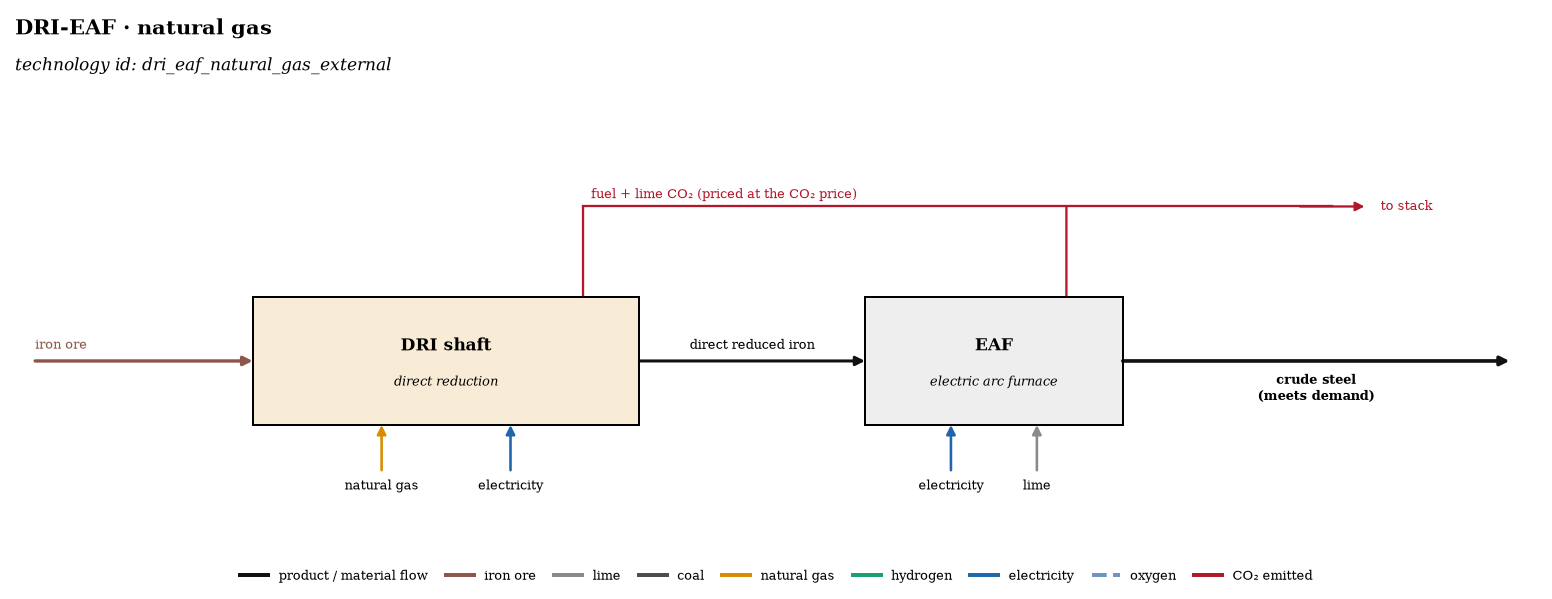

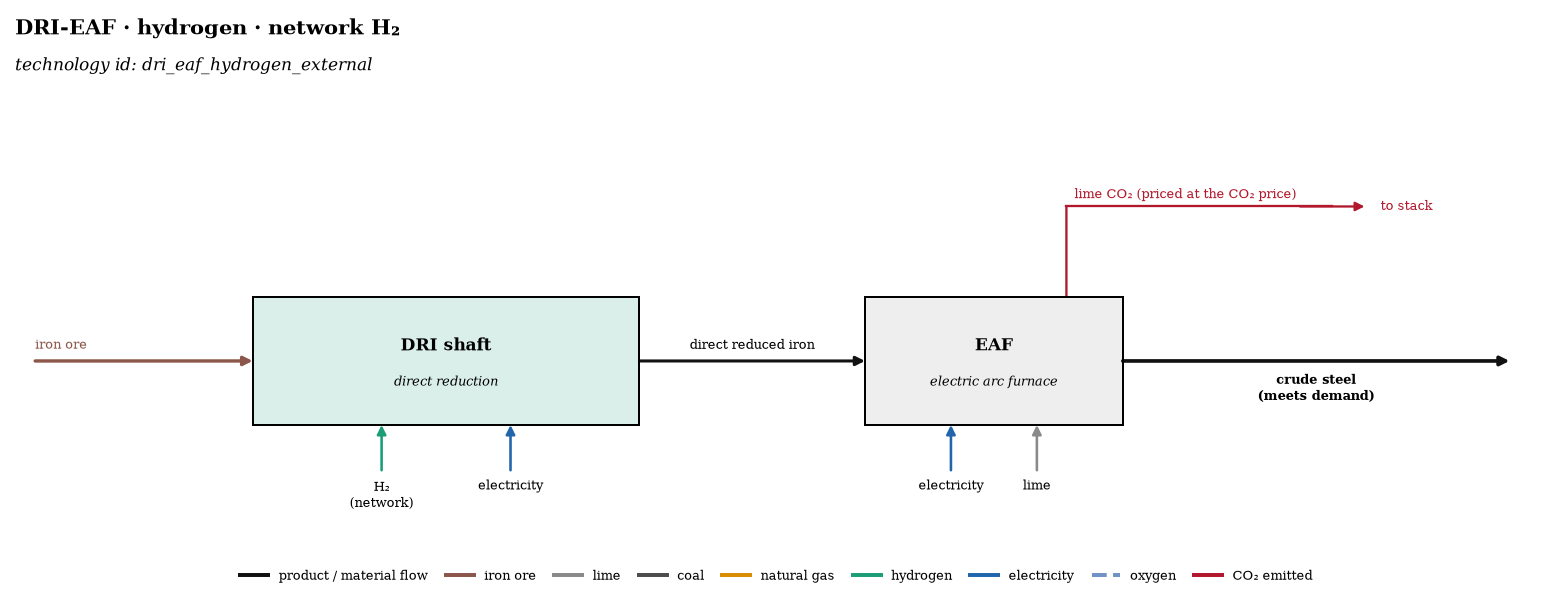

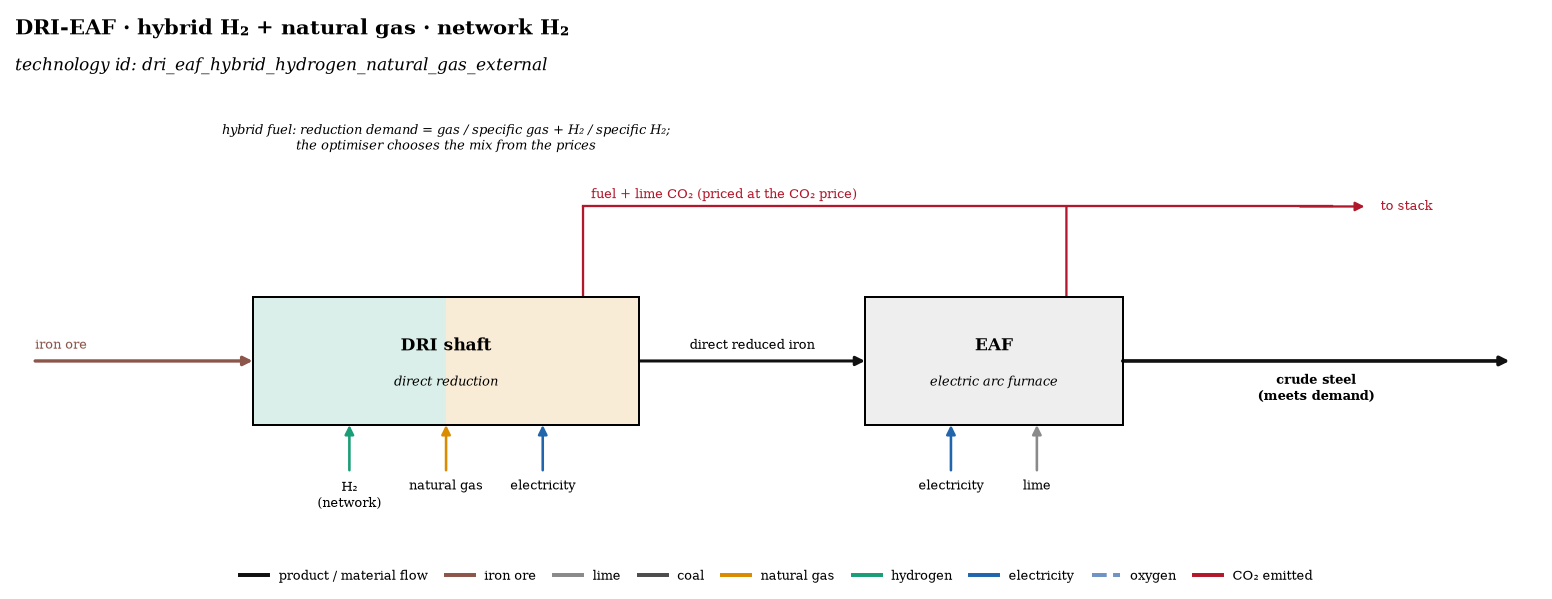

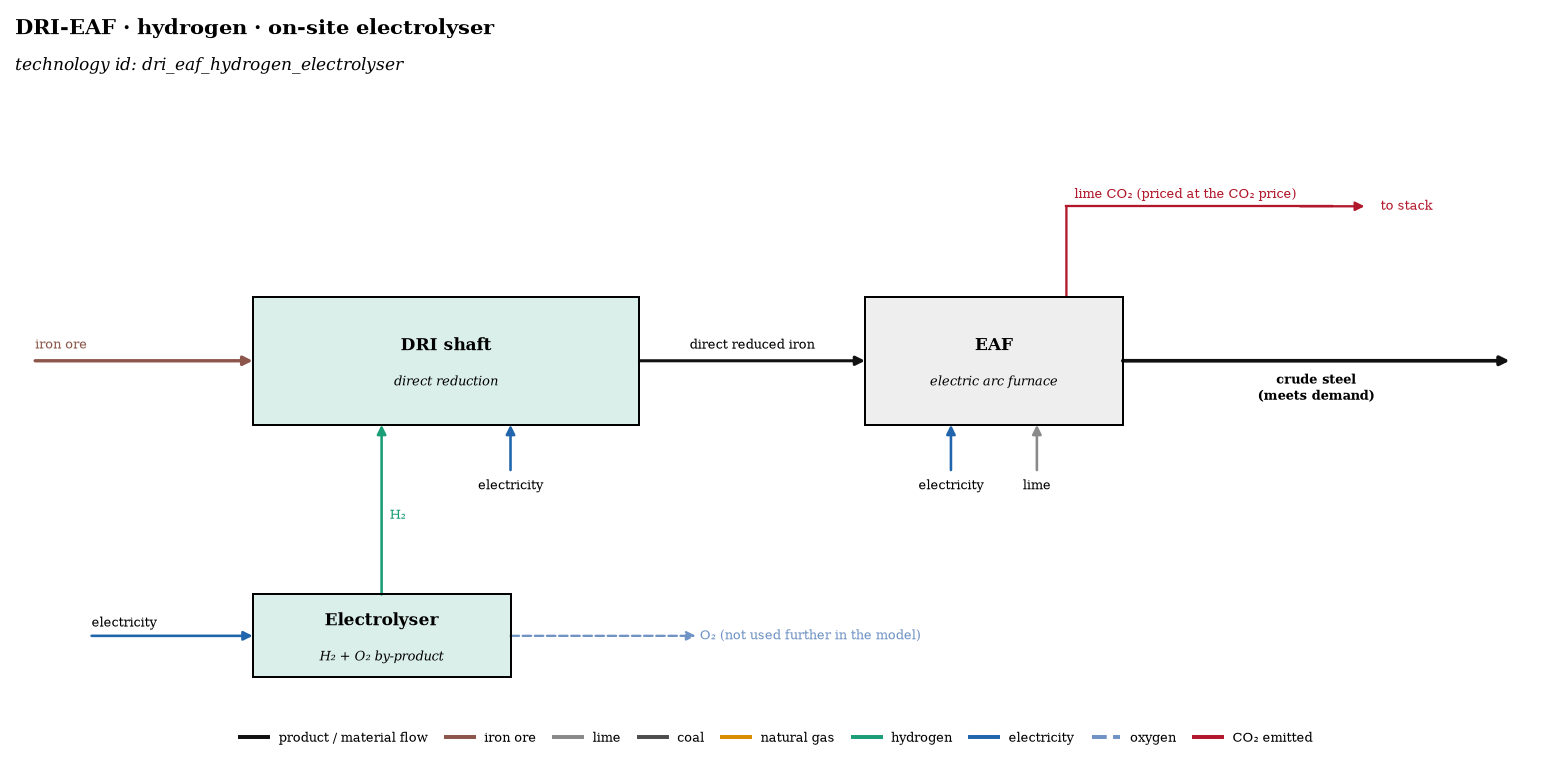

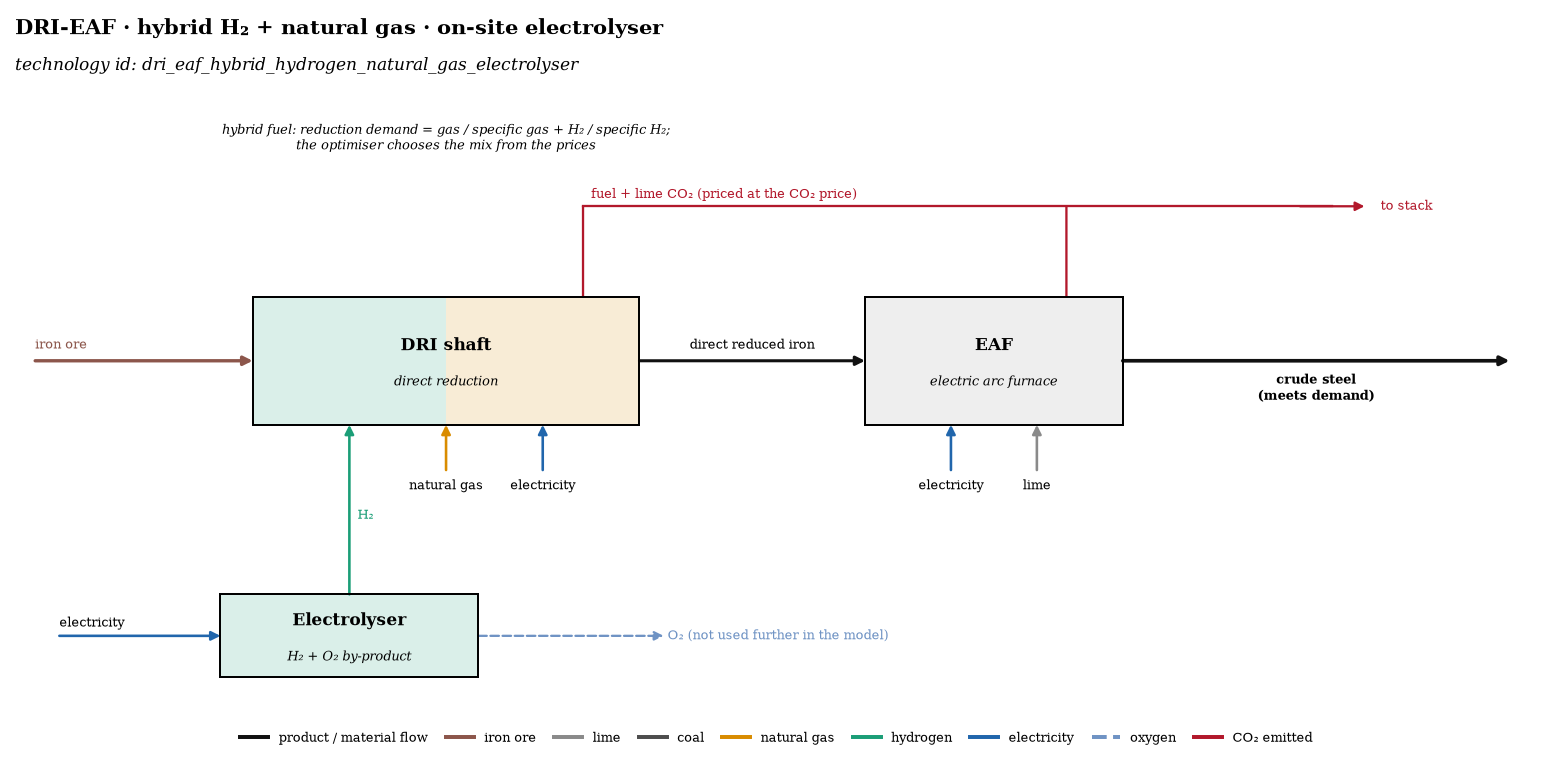

In [10]:
for fuel, supply in STEEL_ORDER:
    draw_steel_config('dri_eaf', fuel, supply)

## What is modelled but not drawn

* **Auxiliary electricity.** Every cement kiln-line stage draws electricity in proportion to its throughput.
* **Operating constraints.** Heat ramping, minimum load, minimum up and down times and the rolling-horizon hand-over between windows apply to every stage.
* **Cost accounting.** Each stage is charged for its fuel and electricity at the scenario prices, and for the priced share of its CO2. Biogenic CO2 from biomass and RDF is physically emitted but its price treatment follows the accounting shares set in the input.
* **Outside the boundary.** Grinding and cement blending, clinker silos, raw-material purchase, and the transport and storage of captured CO2 are not modelled; a captured stream simply leaves the plant.
* **Electrolyser oxygen in steel.** The oxygen co-product is computed but not consumed by any steel stage.